<img src="https://opensource.ellak.gr/wp-content/uploads/sites/5/2019/04/dit-logo.png" alt="HUA - DIT" width="350"/>

## <font color="#005A8C">Machine Learning final project: The Fashion-MNIST dataset</font>
##### MSc in Advances in Computer Science and Information Systems

| <font color="#005A8C">Field</font> | <font color="#005A8C">Details</font> |
| --- | --- |
| **University** | Harokopio University of Athens |
| **Department** | Informatics and Telematics |
| **Course** | Machine Learning |
| **Professor** | Dr. Anastasios Nentidis |
| **Academic Year** | 2025 - 2026 |
| **Student** | **Drosos Katsimpras** |
| **Student ID** | [ais25123](mailto:ais25123@hua.gr) |
| **Application Domain** | <span class="domain-tag">Medical</span> |
| **Delivery Date** | 21st January 2026 |

## Abstract

Machine Learning is widely used to solve classification problems in many application areas. This project presents a structured study of classical machine learning techniques applied to the Fashion-MNIST dataset, which is a commonly used benchmark for image classification tasks.

The main goal of this project is not to achieve the highest possible accuracy, but to clearly demonstrate the full **machine learning workflow**. This includes problem definition, exploratory data analysis, data preprocessing, model selection, model training, hyperparameter tuning, and performance evaluation.

The dataset contains grayscale images of different types of clothing items. An exploratory data analysis is performed to better understand the data and its characteristics. Several supervised machine learning algorithms are implemented and compared, including **Logistic Regression**, **k-Nearest Neghbors**, **Support Vector Machines**, **Decision Trees**, and **Naive Bayes** classifiers. The model performance is evaluated using standard classification metrics and cross-validation, while a confusion matrix  is used to analyze classifications errors.

Last but not least, the results show the advantages and limitations of different algorithms when applied to image data using classical machine learning methods. The project concludes with a discussion of the results, study limitations, and possible future improvements, such as the use of more advanced models. Overall, this work aims to provide a clear, well-structured, and academic demonstration of fundamental machine learning concepts.

## List of Abbreviations

| Abbreviation | Full Name |
| :--- | :--- |
| **EDA** | Exploratory Data Analysis |
| **KDE** | Kernel Density Estimation |
| **SVM** | Support Vector Machine |
| **PCA** | Principal Component Analysis |
| **RBF** | Radial Basis Function (Kernel) |
| **MNIST** | Modified National Institute of Standards and Technology |
| **TP / TN** | True Positive / True Negative |
| **FP / FN** | False Positive / False Negative |
| **CV** | Cross-Validation |

## Chapter 1: Project Setup

- In this chapter, we will present the initial setup of the Machine Learning project. It includes the loading of the required Python libraries, the import of machine learning algorithms, and the acquisition of the dataset used in this project.
- The purpose of this chapter is to establish a consistent environment that will support the exploratory analysis, model development, and evaluation phases that follow.

### 1.1 Load required libraries

The purpose of this step is to import the essential Python packages that provide the framework for data manipulation, visualization, and machine learning implementation.

In [2]:
import time
#==================================
# Data manipulation and analysis
#==================================
import numpy as np
import pandas as pd

#==================================
# Data visualization
#==================================
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.decomposition import PCA

#==================================
# Model preprocessing / validation
#==================================
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, Normalizer, Binarizer
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split

#==================================
# Import Model evaluation metrics
#==================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

#==================================
# Import Optimizers
#==================================
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from scipy.stats import uniform

print("The required libraries has been loaded successfully!")

The required libraries has been loaded successfully!


### 1.2 Import Machine Learning algorithms

We will import the required ML algorithms.

In [3]:
#================================
# Machine Learning algorithms
#================================

# Linear models
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Distance-based model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Probabilistic model
from sklearn.naive_bayes import GaussianNB

# Tree-Based model
from sklearn.tree import DecisionTreeClassifier

# Kernel-based model
from sklearn.svm import SVC

print("The Machine Learning algorithms have been loaded successfully!")

The Machine Learning algorithms have been loaded successfully!


### 1.3 Load the Fashion-MNIST dataset

- The [Fashion-MNIST](https://www.kaggle.com/datasets/zalando-research/fashionmnist) dataset was obtained from Kaggle and loaded into the Google Colab environment. The dataset consists of grayscale images of clothing items, represented as numerical pixel values, along with their corresponding class labels.
- The dataset has two different parts: a training set of 60,000 samples and a testing set of 10,000 samples. Loading both at the start ensures that we maintain a clear separation between the data used for model development and the data used for final performance validation.
- In this step, we pull the raw data from your Google Drive into a Pandas DataFrame. Because image data is high-dimensional (784 features per image), we also need to verify that the load was successfull by checking the shapes of our arrays.

In [4]:
#================================
# Load Dataset
#================================

from google.colab import drive
drive.mount('/content/drive')

# Load training data
train_file = "/content/drive/My Drive/datasets/fashion-mnist_train.csv"
df_train = pd.read_csv(train_file)

# Load testing data
test_file = "/content/drive/My Drive/datasets/fashion-mnist_test.csv"
df_test = pd.read_csv(test_file)

#df_train.head()
print("The Fashion-MNIST dataset has been loaded successfully!")

Mounted at /content/drive
The Fashion-MNIST dataset has been loaded successfully!


## Chapter 2: Define Problem

- The primary objective of this chapter is to establish a framework for the machine learning task at hand. By transitioning from dataset to the problem formulation, we define the boundaries, expectations, and environmental context of the project.
- This phase is critical in the machine learning pipeline as it ensures that the subsequent technical implementation is aligned with a clearly defined goal: the accurate and efficient classification of fashion apparel from high-dimensional image data.


### 2.1 Problem Definition

- The core problem addressed in this project is the automaed identification of fashion products based on low-resolution grayscale imagery. Specifically, the task is a **Supervised Multi-Class Classification** problem. We are provided with a dataset where each instance is a 28 x 28 pixel image (784 features) that has been pre-labeled with a specific category (e.g., "Dress", "Sneaker", "Bag").

- We are using Supervised Learning, which means we show the computer many examples of clothes along with their correct names. The computer learns from these examples so that when it sees a new picture it has never seen before, it can guess the correct category.

- The **challenge** lies in the similarity of the data; unlike simpler digit recognition tasks, fashion items often share similar global shapes. Therefore, the model must learn to distinguish local patterns within the pixels to map each input to the correct one of ten possible output classes.



### 2.2 Task Specification
- **Task type:** Multi-class classification (supervised learning) - We use labeled training data to train the model.
- **Goal:** Build a model that can look at 784 pixel values and correctly predict which of the 10 fashion categories the image belongs to.
- **Input:** 784 features - a number between 0 (white) and 255 (black) representing the darkness of a single pixel in a 28 x 28 image.
- **Output:** One of 10 labels (0 to 9):
  - 0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat, 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot.

### 2.3 Domain Context and Priorities

- This dataset comes from Zalando, a large fashion company. In the world of e-commerce, it is very important to organize products quickly.
  - The problem: The old "MNIST" dataset (handwritten numbers) became too easy for computers. Professionals needed a harder challenge that looks like real-world products.
  - The priority: we need to create an algorithm that is "**robust**". This means the model should not just recognize a perfect picture of a shirt, but should be able to handle different styles of shirts, coats, and shoes accurately.

### 2.4 Methodological Approach

To solve this problem, we will follow a standard machine learning path:

1. **Data Preparation:** The Fashion-MNIST dataset has been loaded, consisting of 60,000 training images and 10,000 test images. The pixel values is originally in the range 0-255, will be scaled to a smaller range (e.g., 0-1) to improve model performance and stability.

2. **Algorithm Selection:** We will test many different types of algorithms, such as:
    - Linear models (Logistic Regression, Linear Discriminant Analysis (LDA))
    - Distance-based models (K-Nearest Neighbors)
    - Probabilistic models (Naive Bayes)
    - Tree-based models (Decision Trees)
    - Kernel-based models (Support Vector Machines (SVM))

3. **Model Evaluation and Comparison:** The performance of the selected algorithms will be evaluated using appropriate classification metrics. In addition, we will compare the models to identify the algorithm that provides the best balance between accuracy and generalization.

4. **Model Selection:** In the end of these steps, the best-performing model will be selected for further tuning and final evaluation on the test dataset.

### 2.5 Success Metrics

In the machine learning pipeline, defining how success is measured is essential to ensure the model's performance is evaluated objectively. For our classification task on the dataset (Fashion-MNIST), relying on a single percentage is often insufficient. Therefore, a multi-faceted evaluation strategy is employed.

The following metrics serve as the primary indicators of model effectiveness:

- **Acccuracy:** measures the percentage of correctly classified images across all 10 clothing categories. It provides an overall view of the model's general classification performance.

- **Precision & Recall:** are used to evaluate how well the model performs for individual classes.
  - Precision indicates how often the model's predictions for a given class are correct.
  - Recall measures the model's ability to correctly identify all instances of that class.

- **F1-Score:** Since many clothing categories have similar visual features, the F1-score is used to provide a balanced measure that combines Precision and Recall. This metric is especially useful when class performance varies across categories.

- **Confusion Matrix Analysis:** is used to visually analytze classification errors. It helps identify which clothing categories are frequently confused with each other, such as distinguishing between visually similar items.

### 2.6 Why Machine Learning?

- Traditional rule-based programming is not suitable for image classification tasks due to the high-dimentional nature of image data. Simple "if-then" rules cannot capture the wide variation in how clothing items such as shirts or boots appear across different images.

- Machine Learning provides a more effective solution by learning patterns directly from data. The dataset has 784 pixel values of each image as input, and as a result the machine learning can learn decision boundaries that separate different clothing categories. This approvach allows the system to scale efficiently to thousands of images while maintaining consistent and reliable classification performance.

### 2.7 Ethincal Considerations / Risks

- The Fashion-MNIST dataset does not include personal or sensitive data, so there are no direct privacy concerns. However, ethical issues can still exist in machine learning projects. Some clothing categories may appear more ofthen than others, which can lead to biased predictions.

- In addition, machine learning models can be mishandled if their limitations are not clearly explained. For this reason, model results should be interpreted carefully and only within the scope of this project.

- Last but not least, in application domains such as healthcare or criminal justice, additional ethical requirements would apply, including careful dataset selection, bias analysis, transparency, and strict protection of sensitive personal data.

### 2.8 Assumptions & Constraints

- This project assumes that the Fashion-MNIST dataset is correctly labeled and suitable for image classification tasks. Each image is treated as an independent sample, without considering any relationship between images.
- The project is limited to classical machine learning algorithms that use pixel values as input, which may not fully capture image structure. The time and computational limits restrict the number of models and hyperparameter combinations that can be tested.

## Chapter 3: Exploratory Data Analysis

The goal of this chapter is to explore and understand the Fashion-MNIST dataset applying machine learning models. Exploratory analysis helps verify data quality, understand data structure, and identify potential challenges for model training. In shortly, we can say the following:

- The purpose is to examine the structure, size, and content of the dataset.
- And also, we will gain initial insights through basic statistics and visualizations.




### 3.1 "Peek" at the data

Purpose: We will examine actual data values to understand structure, identify issues, and gain insight about the dataset.

#### 3.1.1 Dataset dimensions

In the Machine Learning methodology, the first step is to "peek" at the scale of our data, before diving into the complex analysis. We will check the dimensions ensures that the files were loaded correctly and that we have a number of observations for the machine learning algorithms to learn the patterns of the clothing items effectively. This step also confirms the number of features (pixels) we are dealing with, which is a critical piece of information for the dimensionality reduction -if it is neccessary- we will perform later.

In [5]:
print("=" * 40)
print("Dataset Dimensions")
print("=" * 40)

# Data loading - verification
print(f"\nTraining data loaded: {df_train.shape[0]} rows, {df_train.shape[1]} columns.")
print(f"Testing data loaded: {df_test.shape[0]} rows, {df_test.shape[1]} columns.\n")

Dataset Dimensions

Training data loaded: 60000 rows, 785 columns.
Testing data loaded: 10000 rows, 785 columns.



Considering the results of the above code, we can mention the following:

- **Observations (Rows)**: The 60,000 rows in the training set provide a library of examples for the model, which is essential for achieving high accuracy in complex image recognition tasks.
- **Features (Columns)**: As we can see, the 785 columns represent our variables. Specifically, 784 of these are the individual pixels that make up the 28x28 image, while the final column is the lable that identifies what the cloth is.
- **High Dimensionality**: Having 784 pixels features means that our dataset is "high-dimensional". For this reason, we will need Feature Engineering to simplify the data.



#### 3.1.2 Load the data

In this step, after importing the CSV files into a Dataframe, we use the head() method to perform an inspection of the raw data. This allows us to confirm that the features columns(pixel 1 to pixel 784) and the target labels have been mapped correctly. Viewing the first few rows helps us verify the data integrity before applying anything else.

In [6]:
df_train.head(20)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


In [7]:
df_train.isnull().any().sum()

np.int64(0)

In [8]:
pixel_min = df_train.drop('label', axis=1).values.min()
pixel_max = df_train.drop('label', axis=1).values.max()

print(f"Min pixel value: {pixel_min}")
print(f"Max pixel value: {pixel_max}")

Min pixel value: 0
Max pixel value: 255


#### 3.1.3 Does the data make sense?

- The data makes sense because:
  - We performed a simple check on the dataset to confirm that the values align with our expectations for digital images. We are looking for anything that seems impossible or out of place.

- Do the columns and values make sense?
  - Yes, and especially for characterictics we can mention the following:
    - **Pixel Value & Range**: We have digital images in grayscale and values between 0 (black) and 255 (white). The results shows to us that no pixel has negative value or a value higher than 255.
    - **Missing data**: We check for "null" or empty cells. The isnull().sum() check return 0, meaning there are no missing values in the 60,000 observations. This is vital because every pixel is a piece of information required to define the shape of the clothing.
    - **Dimensionality**: We confirmed that every row has exactly 784 features (pixels), allowing for a 28x28 square image.

#### 3.1.4 Data Type of Each Attribute

In this subsection, we verify that all pixel are stored as numerical data types rather than text strings, as machine learning algorithms rely on mathematical operations to identify patterns.

- We use the dtypes attribute to check the data format of every column.
- The Fashion-MNIST dataset should have all features and the label as **integers**.
- We ensuring these are numerical types and prevents errors during the scaling and normalization phases.

In [9]:
df_train.dtypes
#print(df_train.dtypes.value_counts())

,0
label,int64
pixel1,int64
pixel2,int64
pixel3,int64
pixel4,int64
...,...
pixel780,int64
pixel781,int64
pixel782,int64
pixel783,int64


We are taking a look at the output. It confirms that every attribute in the dataset is a 64-bit integer. This is the ideal format for our analysis because pixel intensities (0-255) and category labels (0-9) are whole numbers. We ensures that our data is ready for the algorithms we will apply later.

#### 3.1.5 Do we have a target variable?

It is important to understand that in supervised learning, it is vital to identify the **Target Variable**, which is the specific value the model is trying to predict. In our dataset, the target is the "label" column. We will now verify that this column contains the expected range of categories (0-9) and nothing else.

In [10]:
df_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df_train.tail()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59999,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# unique number found in the label column
unique_labels = df_train['label'].unique()
unique_labels.sort() # Sort them so they are easy to read

print(f"Unique values in label column: {unique_labels}")

# min and max of these values
print(f"Minimum label: {df_train['label'].min()}")
print(f"Maximum label: {df_train['label'].max()}")

Unique values in label column: [0 1 2 3 4 5 6 7 8 9]
Minimum label: 0
Maximum label: 9


#### 3.1.6 Descriptive Statistics

The goal of this analysis is to gain a high-level quantitative understanding of our features. We use the describe() method to calculate key statistical measures for all 784 pixel attributes and the target label. This helps us identify the typical intensity of pixels accross the images and detect if any features have unusual variations.


##### 3.1.6.1 describe() method

After explaining the general purpose of descriptive statistics, we are going to use the describe() function on the Pandas DataFrame to calculate the summary statistics for our dataset.

This describe() method returns 8 statistical properties for each attribute:

- **Count**: Confirms that each pixel has 60,000 observations, verifying no missing values.
- **Mean**: The average intensity of each pixel. Low means near the edges suggest those areas are mostly black (background).
- **Standard Deviation**: measures the variation in pixel values (how "spread out" our data is from the average(mean)). A low σ suggests the pixel varies significantly between clothing items.
- **Minimum value**: the lowest value found (0.00 for all pixels)
- **25th Percentile**: the value under which 25% of the instances can be found
- **50th Percentile (Median)**: the middle value that splits the distribution in half.
- **75th Percentile**: the value under which 75% of the instances can be found
- **Maximum value**: The highest value found (typically 255 for most center pixels)

In [13]:
df_train.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,4.500000,0.000900,0.006150,0.035333,0.101933,0.247967,0.411467,0.805767,2.198283,5.682000,...,34.625400,23.300683,16.588267,17.869433,22.814817,17.911483,8.520633,2.753300,0.855517,0.07025
std,2.872305,0.094689,0.271011,1.222324,2.452871,4.306912,5.836188,8.215169,14.093378,23.819481,...,57.545242,48.854427,41.979611,43.966032,51.830477,45.149388,29.614859,17.397652,9.356960,2.12587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,16.000000,36.000000,226.000000,164.000000,227.000000,230.000000,224.000000,255.000000,254.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.00000


According to the table from the method output, we can mention several key patterns:

- Before this method, we checked the label verification manually with a simple python code. This method gave to us that the label column shows a mean of 4.5. Since our labels are 0 to 9, an average of 4.5 is a strong mathematical hint that our classes are balanced.
- Many early pixels (like pixel1 to pixel4), the mean is very close to zero, and the 25%, 50%, and 75% values are all 0.00. This confirms that the corners and edges of the images are almost always black background across the entire dataset.
- When we check the center pixels, the mean and standard deviation increase significantly. This means that the clothing shapes is concentrated in the middle of the 28x28 grid.
- Last but not least we can say about the standard deviation the following:
  - Low Standard Deviation (near 0): this means the pixel is almost the same in every single photo..
  - High Standard Deviation: this means the pixel changes a lot. Sometimes it is black(0), sometimes it is white (255), and sometimes it is gray.

##### 3.1.6.2 Class Distribution

Purpose: Summarise distribution of instances across classes

In classification problems, it's crucial to understand how balanced the class values are.
- Highly imbalanced datasets (a lot more observations for one class than another) are common in real-world scenarios and may require special handling during data preperation. We examine the class distribution to determine if imbalance exists and plan our modeling strategy accordingly.

In [14]:
#df_train.groupby('label').size()

# dictionary to map numbers to names
label_names = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}

# group by label - rename the index for the report
distribution = df_train.groupby('label').size().rename(index=label_names)
print(distribution)

label
T-shirt/top    6000
Trouser        6000
Pullover       6000
Dress          6000
Coat           6000
Sandal         6000
Shirt          6000
Sneaker        6000
Bag            6000
Ankle boot     6000
dtype: int64


As noted in the project, real-world datsets often are imbalanced. However, our Fashion-MNIST training set is perfectly balanced. This is an advantage for the project because:

- **Standard Metrics are reliable**: we can use Accuracy as a primary success metric because the model won't be "overhelmed" by a single large class.
- **No Re-sampling Needed**: There is no minority class, so we don't need to implement complex "Under-sampling" or "Over-sampling" techniques like SMOTE.
- **Fair Learning**: The classifier will pay equal attention to every clothing type during training.

##### 3.1.6.3 Correlation between attributes

In this subsection, we investigate the relationship between different pixel features. Correlation measures the statistical relationship between two variables, indicating how they tend to move together. In image data, we expect a high degree of correlation between neighboring pixels, as they often represent the same of a cloth (e.g., a sleeve or a neckline).

Identifying correlated features is important because:

- **Redundancy**: If two pixels are perfectly correlated, they provide the same information, which can lead to "over-fitting".
- **High correlation** between features can sometimes make it difficult for certain algorithms to determine the individual importance of each feature.
- If we find high correlation across the dataset, it provides a strong reason to use Principal Component Analysis (PCA) to compress these correlated pixels into fewer, more meaningful components.

According to the slide 11 of lecture 9 of the Machine Learning course:

-  **Pearson Correlation Coefficient** ranges from -1.0 to 1.0 :
    - **1.0** means a perfect positive correlation: the values of one variable increase as the values of another increase.
    - **-1.0** means a perfect negative correlation: the values of one variable decrease as the values of another increase.
    - **0.0** means no linear correlation between the two variables

- **Practical comment** : High correlations between features may indicate redundancy. If two features are highly correlated ( r >0.9 ), we might consider one to reduce dimensionality and prevent multicollinearity issues in our models.

- We calculate the correlation matrix using Pearson's method to identify which features provide unique information versus those that may be redundant.

In [15]:
df_train.corr(method='pearson')

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
label,1.000000,-0.000674,0.002944,-0.010439,-0.007111,-0.004632,-0.011045,-0.036765,-0.085211,-0.161552,...,-0.362614,-0.258380,-0.183131,-0.090568,-0.077340,-0.066936,-0.018038,0.045598,0.059960,0.021772
pixel1,-0.000674,1.000000,0.297899,0.067550,0.046608,0.026630,0.026172,0.012095,0.012218,0.009637,...,-0.000642,0.004625,0.004605,0.000969,-0.002306,-0.002441,-0.000108,0.008765,0.026389,0.041582
pixel2,0.002944,0.297899,1.000000,0.575029,0.138710,0.054354,0.033185,0.022763,0.017127,0.016809,...,0.000492,0.004857,0.006811,0.002083,-0.004431,-0.002342,0.004273,0.014218,0.021297,0.022162
pixel3,-0.010439,0.067550,0.575029,1.000000,0.387466,0.118135,0.087300,0.060927,0.035920,0.029712,...,0.010131,0.016743,0.018358,0.006171,-0.003825,-0.001501,0.006860,0.013152,0.009946,0.015657
pixel4,-0.007111,0.046608,0.138710,0.387466,1.000000,0.573172,0.325684,0.242954,0.140955,0.085253,...,0.009684,0.018697,0.023373,0.016718,0.009681,0.010095,0.023942,0.012392,0.003075,0.008423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel780,-0.066936,-0.002441,-0.002342,-0.001501,0.010095,0.021505,0.032305,0.027024,0.019414,0.024837,...,-0.074375,-0.009124,0.042812,0.336699,0.790103,1.000000,0.749528,0.349021,0.178599,0.073398
pixel781,-0.018038,-0.000108,0.004273,0.006860,0.023942,0.025974,0.038563,0.030464,0.026227,0.034158,...,-0.042349,0.008555,0.045394,0.130783,0.439260,0.749528,1.000000,0.645809,0.334519,0.133817
pixel782,0.045598,0.008765,0.014218,0.013152,0.012392,0.028863,0.044121,0.029457,0.022724,0.020953,...,-0.002807,0.034069,0.073942,0.092657,0.152471,0.349021,0.645809,1.000000,0.658962,0.225502
pixel783,0.059960,0.026389,0.021297,0.009946,0.003075,0.022941,0.030806,0.016126,0.005938,0.000074,...,0.001898,0.026530,0.054193,0.077633,0.101066,0.178599,0.334519,0.658962,1.000000,0.451929


The generated Pearson correlation matrix confirms several expected patterns for the Fashion-MNIST dataset:

- We observe very high correlation coefficients between pixels, such as 0.79 between pixel 779 and pixel 780. The neighboring pixels often represent the same physical part of a clothing item.
- Many pixel pairs show correlations higher than 0.70, which means significant redundancy across the feature space. These high correlations suggest that the 784-dimensional space can be simplified.
- This high level of dimensionality justifies the use of PCA. By transforming these correlated pixels into uncorrelated components, we can reduce it while retaining the most critical information, leading to faster and more stable model training.

##### 3.1.6.4 Skew of Univariate Distributions

We will measure the asymmetry of the distribution of each feature. It indicates whether the data is concentrated on one side or follows a symmetric pattern. We need to understand the skew of Univariate Distributions to help us to identify features that may need transformation for better model performance.

In [16]:
df_train.skew()

,0
label,0.000000
pixel1,143.091194
pixel2,90.419440
pixel3,127.905289
pixel4,44.613085
...,...
pixel780,2.700864
pixel781,4.254187
pixel782,7.961132
pixel783,14.290953


After the output, we can mention the following:

- The skewness for the label is 0.000000. This is perfect score because a skew of zero confirms that the distribution of our classes is perfectly symmetrical.
- Most pixel attributes show very high positive skewness:
  - This means that in image data, a high positive skew indicates that the majority of pixels are "dark" (close to 0), with only a small number of "bright" pixels forming the clothing item.
  - Also confirms that our images have a lot of empty background space, especially at the edges (pixel1), where the skew is highest.
- Many machine learning algorithms perform better with normally symmetric data, and these high skewness values justify the Data Preperation will take in Chapter 4, such as rescaling and binarization, to make the features more manageable for the model.

#### 3.1.7 Univariate Plots

In this section, we transition from numerical summaries to visual representations of our data. Univariate analysis focuses on examining each feature individually to understand its distribution, central tendency, and spread. Since our dataset contains 784 pixel features, we will focus our visualization on a prepresentative sample of pixels to observe how the data behaves in different regions of the image (such as the edge and the center).

##### 3.1.7.1 Histograms plots

Histograms provide a bar-chart-like representation of the intensity frequencies for specific pixels. By plotting a sample of pixels from different areas of the 28x28 grid, we can see exactly how the "black background" dominates the distribution and how the "clothing pixels" create variety.

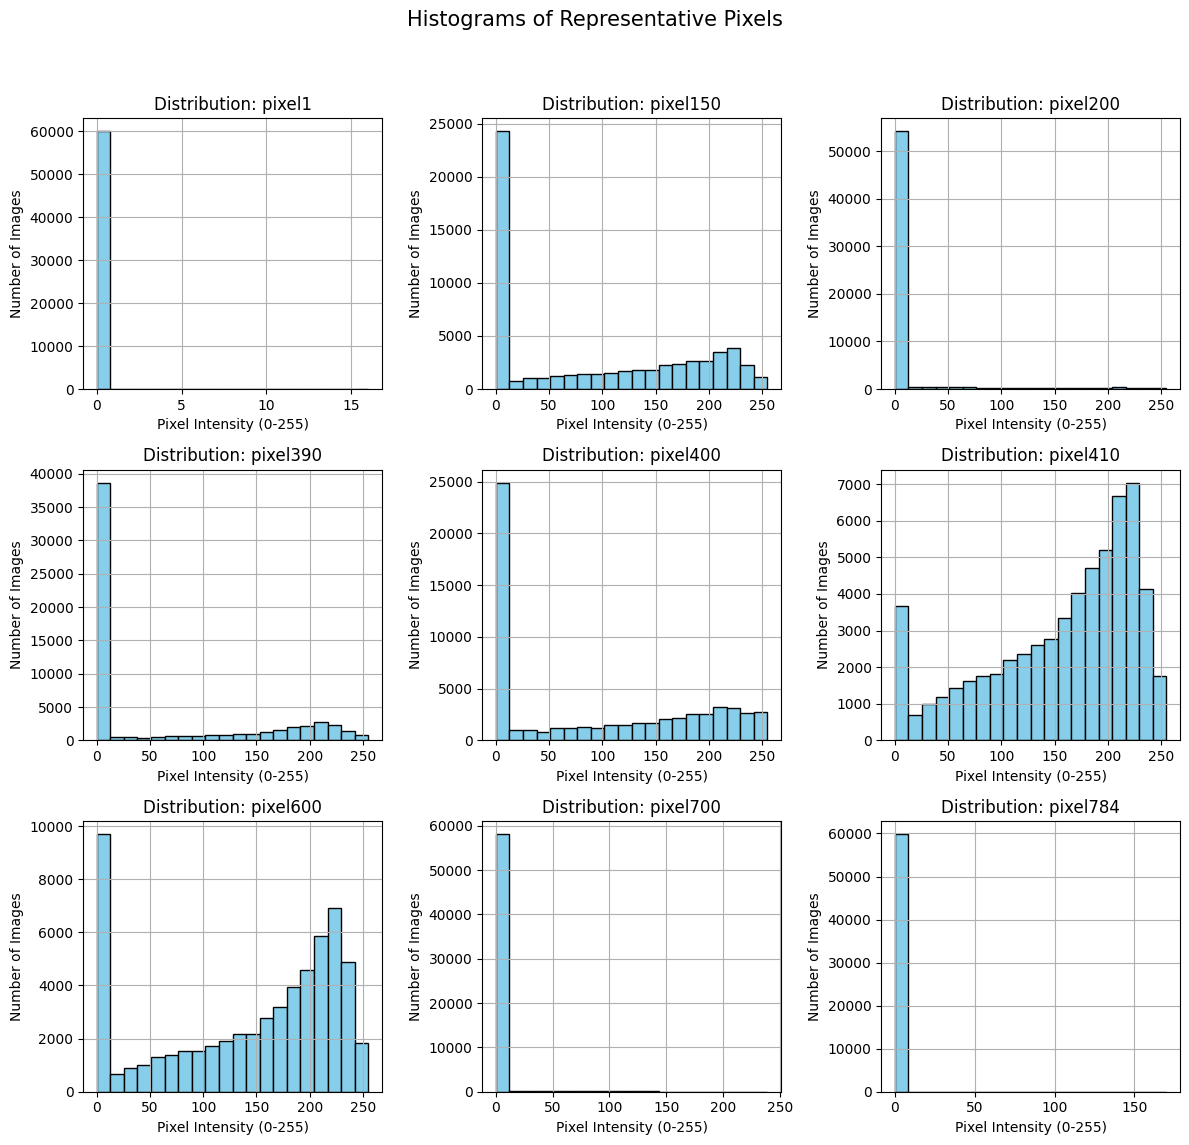

In [17]:
# 9 pixels from different areas:
pixels = ['pixel1', 'pixel150', 'pixel200', 'pixel390', 'pixel400', 'pixel410', 'pixel600', 'pixel700', 'pixel784']

# 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Histograms of Representative Pixels", fontsize=15)

for i, pixel in enumerate(pixels):
    row, col = i // 3, i % 3
    df_train[pixel].hist(ax=axes[row, col], bins=20, color='skyblue', edgecolor='black')
    axes[row, col].set_title(f"Distribution: {pixel}")
    axes[row, col].set_xlabel("Pixel Intensity (0-255)")
    axes[row, col].set_ylabel("Number of Images")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Based on the results from the histogram plots, we can say the following:

- Most pixels are black, because if we can see all plots show a very tall bar at 0, which means the black background is the most common part of the images.
- We selected the pixel 1 and pixel 784, and we realized that the pixels in corners are "dead", which means that there is almost no other data except for the black background.
- On the other hand, we selected center pixels like pixel 400 and pixel 410, which are showing values spread across the whole x-axis(0-255), meaning they contain the actual details of the clothes.
- Also, the massive spike at zero visually proves the "positive skew" we found in our numerical check.

##### 3.1.7.2 Density plots

In this subsection we will use the Density plots, also known as Kernel Density Estimation (KDE), provide a smoothed, continuous version of the histogram. Instead of discreate bars, these plots show the probability distribution of pixel intensities as a continuous curve. This visualization is particularly useful for indentifying the "bi-modal" nature of the pixel data - where one peak typically represents the dark background and a second, smaller peak represents the presence of garment. Using the same nine representative pixels allows for a direct comparison with the previous histogram results.

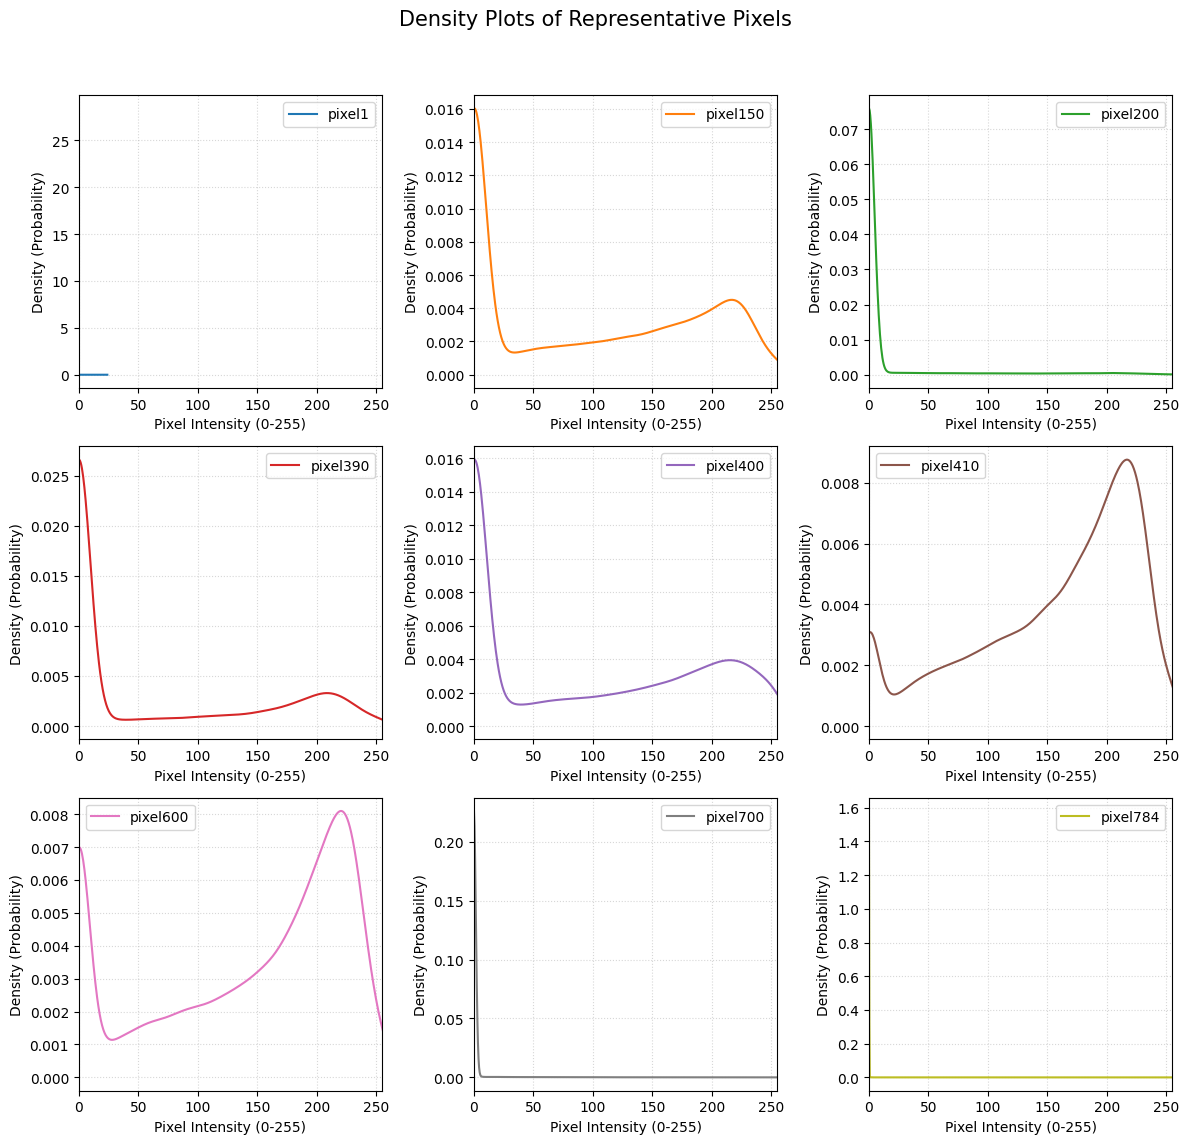

In [18]:
# we will use the same pixels from histograms plots
df_train[pixels].plot(kind='density', subplots=True, layout=(3,3), sharex=False, figsize=(12, 12))

# Adding professional labeling to each subplot
for ax in plt.gcf().get_axes():
    ax.set_xlabel("Pixel Intensity (0-255)")
    ax.set_ylabel("Density (Probability)")
    ax.set_xlim(0, 255)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle("Density Plots of Representative Pixels", fontsize=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Based on results of this kind of plots (Density), we can say:

- These kind of plots, in the same pixels which we selected for histograms plots, show the same data results in alternative view.
- Also, the center pixels (pixel400, pixel600) show two peaks: one for the background at 0, and one for the clothing (near 200).
- In additional, in the edge pixels (pixel1, pixel700, and pixel784) show only one very sharp, thin peak at zero.
- Last but not least, on the right side of the center pixel plots show that the middle of the image has the most information.

##### 3.1.7.3 Box Plots

Boxplots summarize the distribution of each attribute, drawing a line for the median (middle value) and a box around the 25th and 75th percentiles (the middle 50% of the data). The whiskers give an idea of the spread of the data and dots outside of the whiskers show candidate outlier values (values that are 1.5 times greater than the size of spread of the middle 50% of the data).

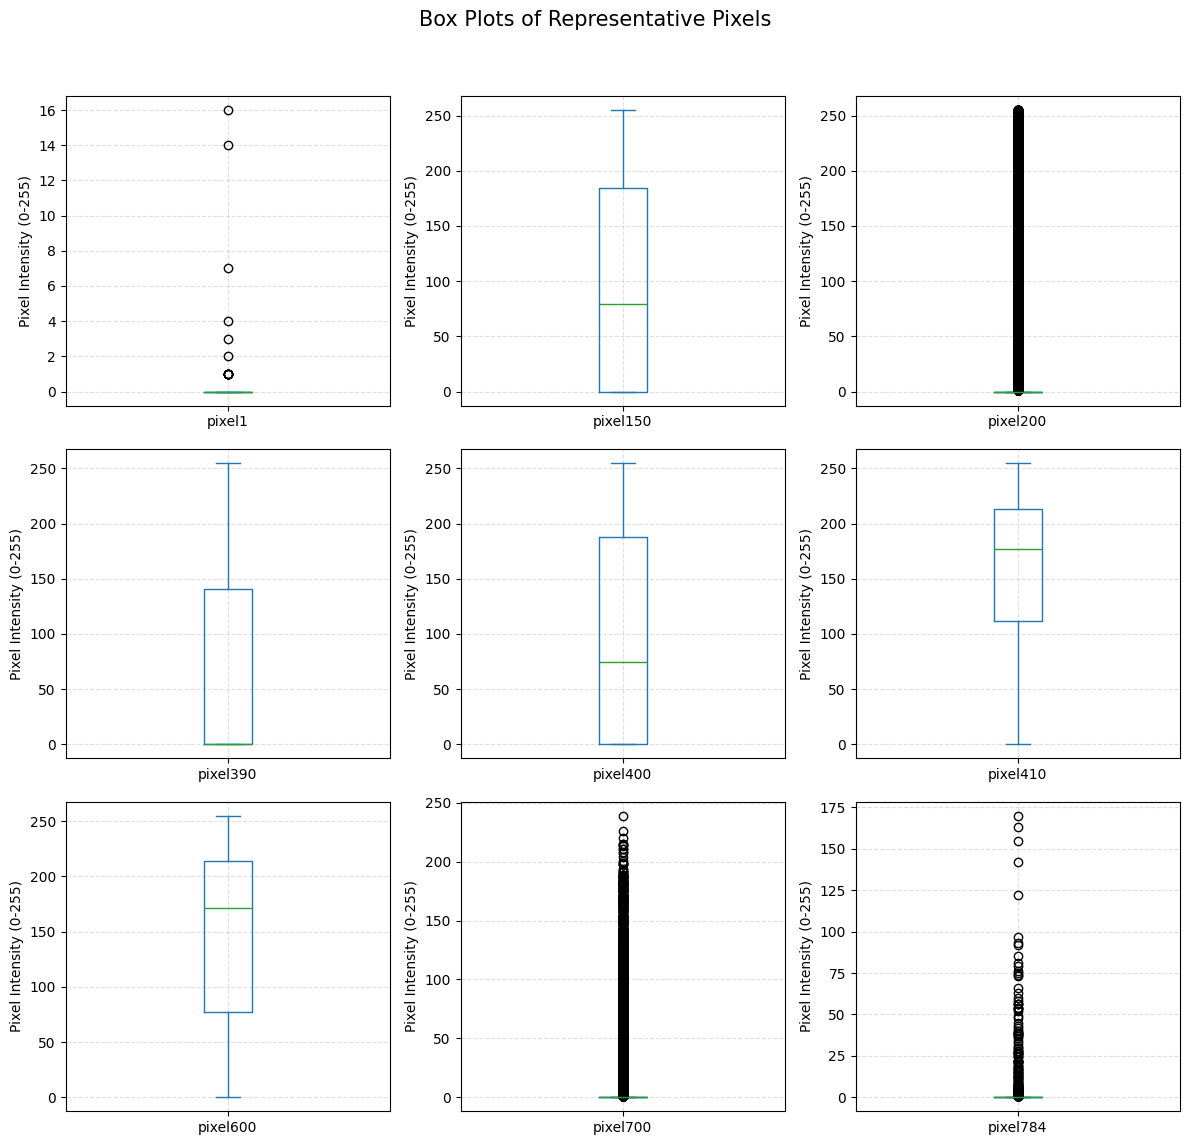

In [19]:
# generate Box Plots
df_train[pixels].plot(kind='box', subplots=True, layout=(3,3), sharex=False, sharey=False, figsize=(12, 12))

for ax in plt.gcf().get_axes():
    ax.set_ylabel("Pixel Intensity (0-255)")
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Box Plots of Representative Pixels", fontsize=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- The green line (median) shows that for many pixels, the middle value is zero, confirming the images have a lot of black background.

- The size of the box tells us how much the color changes, central pixels have larger boxes because they contain the details.

- Finally, the circles represent "outliers", which are rare cases where a piece of clothing appears in a spot that is usually empty background.

After the output, we can mention the following:

- For edge pixels such as pixel 1 and pixel 784, the "box" is flat at a value of zero. This confirms that as least 75% of the observations for these features are black background, reinforcing the high positive skewness (143.09 for pixel 1) reported earlier.
- On the other hand, the central pixels like pixel 410 and pixel 600 display much larger boxes with median lines located at higher intensity values. This high variance indicates that these features capture details from the clothing items, making them the most critical features for the classification tasks.
- Outlier Analysis: Many pixels, like pixel 200 and pixel 700, show a high frequency of outliers represented by individual dots reaching toward the 255 intensity mark. This shows that even background-heavy pixels can sometimes contain parts of a cloth.
- Our box plots show that many pixels (like pixel 1 and pixel 784) are almost always black background. This means they don't give the model any useful information to tell the difference between a shirt and a shoe. Because we have 784 pixels, but many are "empty" or repeat the same information, our data is "redundant" (it has more than it needs).

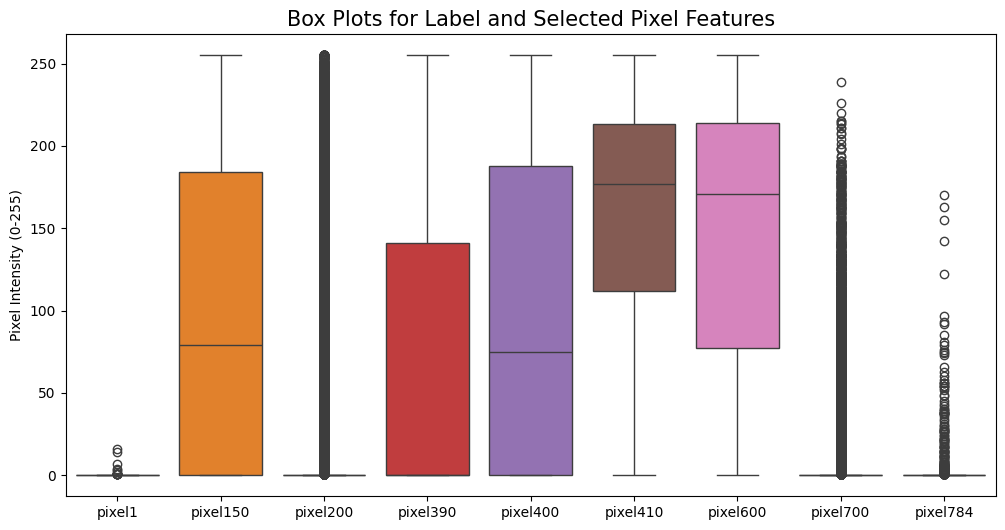

In [20]:
# create the figure
plt.figure(figsize=(12, 6))

# use Seaborn to plot the selected data
sns.boxplot(data=df_train[pixels])

plt.title('Box Plots for Label and Selected Pixel Features', fontsize=15)
plt.ylabel('Pixel Intensity (0-255)')

plt.show()

After the creation of this plot, we can say that this combined plot visually highlights how pixel information changes based on its location in the 28 x 28 image grid.

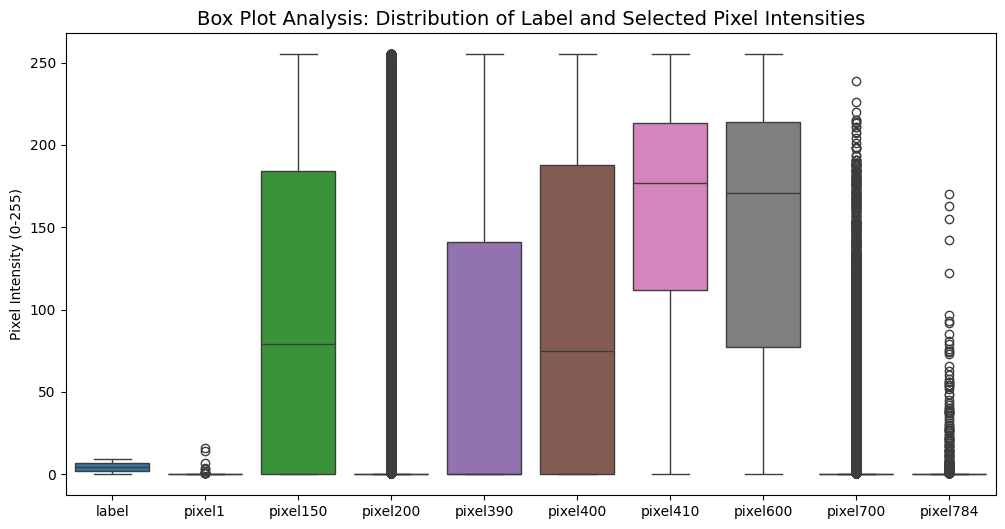

In [21]:
# we select 'label' and 9 pixels from different areas:
pixels_label = ['label', 'pixel1', 'pixel150', 'pixel200', 'pixel390', 'pixel400', 'pixel410', 'pixel600', 'pixel700', 'pixel784']

# we create the plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_train[pixels_label])

plt.title('Box Plot Analysis: Distribution of Label and Selected Pixel Intensities', fontsize=14)
plt.ylabel('Pixel Intensity (0-255)')

plt.show()

In the above output, we included the "label" in this combined box plot, which visually demonstrates the difference in scale between the input data (pixels) and the target variable (the label). We can see that the label box is very small and stays near the bottom. This is because our labels are only numbers from 0 to 9 (representing different clothes), while our pixels go all the way up to 255. This visual contrast shows that our target variable is on a much smaller scale than our image data.

First 5 entries of the label column:

   label
0      2
1      9
2      6
3      0
4      3


/tmp/ipython-input-3805740320.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=target_df, palette='viridis')


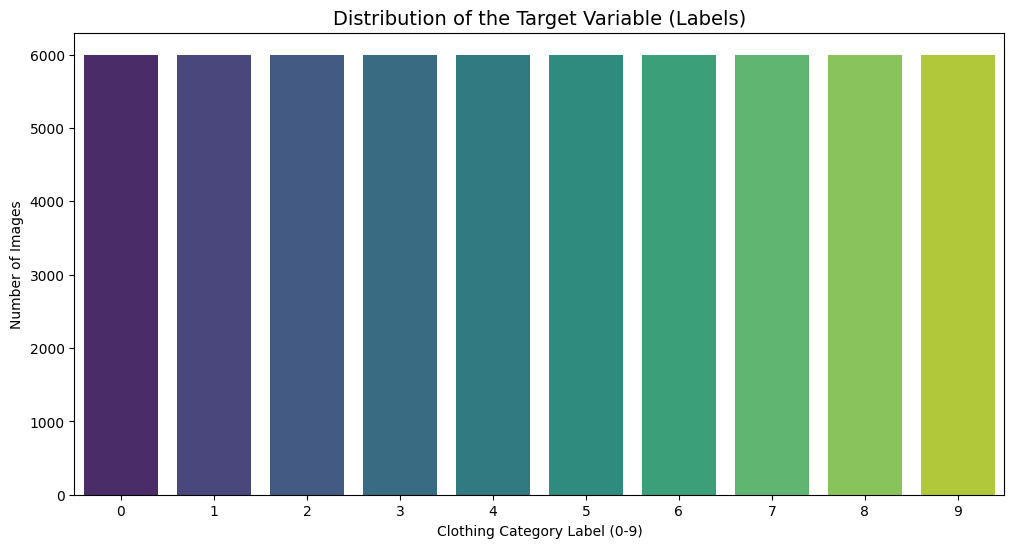

In [22]:
# isolate the "label" column
target_df = df_train[['label']]

# view first entries
print("First 5 entries of the label column:\n")
print(target_df.head())

plt.figure(figsize=(12, 6))
sns.countplot(x='label', data=target_df, palette='viridis')

plt.title('Distribution of the Target Variable (Labels)', fontsize=14)
plt.xlabel('Clothing Category Label (0-9)')
plt.ylabel('Number of Images')
plt.xticks(range(10)) # Ensure all 10 labels are shown on the x-axis
plt.show()

In the above plot, we can see visually that the dataset is perfectly balanced. Every type of clothing has the same number of images (6,0000). This is the result we saw in 3.1.6.2 (Class Distribution) subsection.

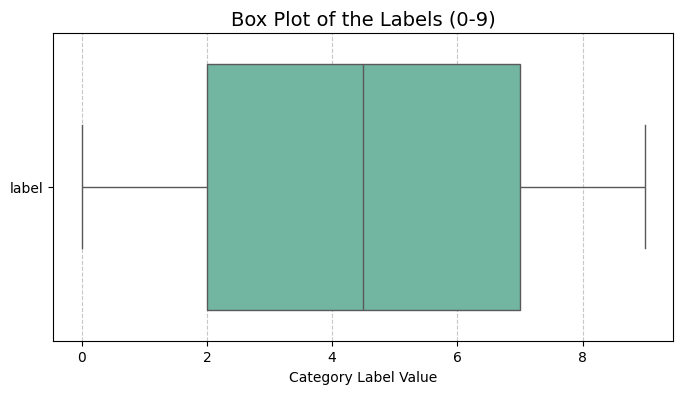

In [23]:
# generate the boxplot for the label column - we will use again the variable: target_df which we created before
plt.figure(figsize=(8, 4))
sns.boxplot(data=target_df, orient='h', palette='Set2')

plt.title('Box Plot of the Labels (0-9)', fontsize=14)
plt.xlabel('Category Label Value')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

The numerical output we saw in 3.1.6.1 describe() method, now we can see on the above plot.
- This summarizes the range of our 10 clothing categories.
- The median line is at 4.5, and the box is perfectly centered between the labels 0 and 9.
- This perfect symmetry is a visual example that confirms our dataset is balanced and contains no incorrect or outliers labels.

#### 3.1.8 Multivariate Plots

In the previous section and subsections, we performed univariate analysis to understand each pixel and label individually. In this section, we move to Multivariate plots to explore the relationships between different variables.

The purpose of multivariate analysis is to see how pixels interact with one another and with the target label. The images are a collaction of pixels that have shapes, we expect many pixels to be "correlated" (meaning they change together). We will try to understand these connections because it helps us identify redundant information and justifies why we can later simplify our data using techniques like PCA.

##### 3.1.8.1 Correlation Matrix

A Correlation Matrix is a table showing "correlation coefficients" between variables. Each cell in the table shows the relationship between two pixels:

- High Positive Correlation (near 1.0): When one pixel gets brighter, the other one usually does too. This happens when pixels are close together in the same part of a garment.
- Zero Correlation (near 0.0): The pixels have no relationship. For instance, a corner pixel and a center pixel might not change together.
- Negative Correlation (near -1.0): this values means that one pixel gets brighter, and the other gets darker.

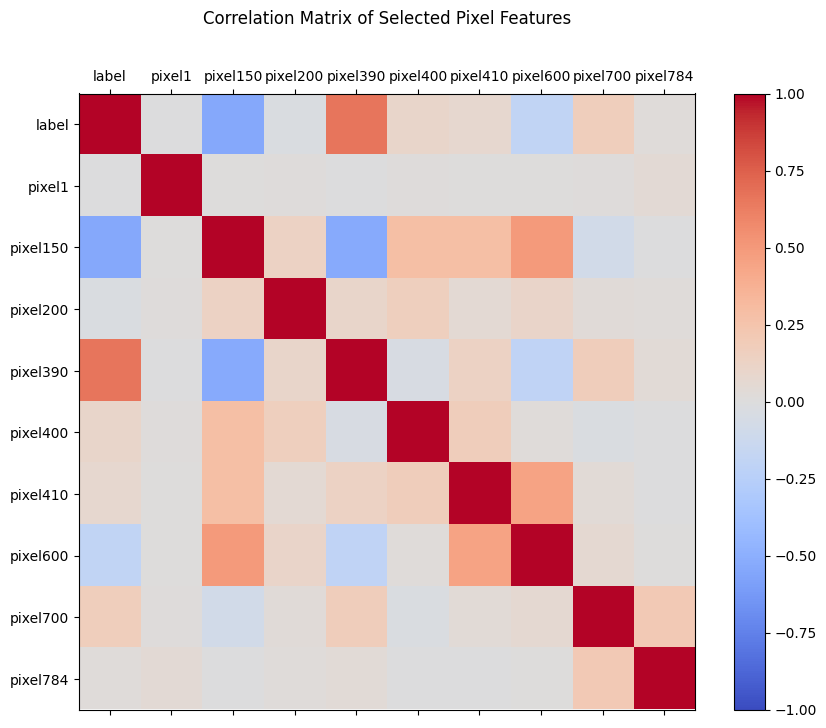

In [24]:
correlations = df_train[pixels_label].corr()
# create the correlation matrix plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(cax)

# Set ticks and labels
ticks = np.arange(0, len(pixels_label), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(pixels_label)
ax.set_yticklabels(pixels_label)

plt.title('Correlation Matrix of Selected Pixel Features', y=1.1)
plt.show()

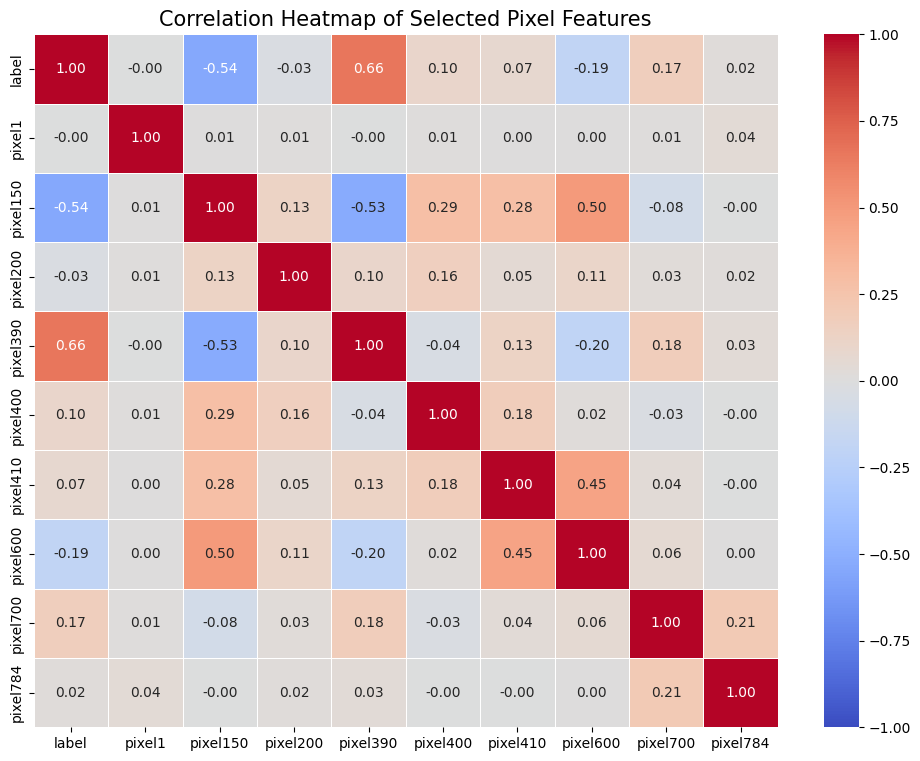

In [25]:
# calculate the Pearson correlation matrix
correlations_subset = df_train[pixels_label].corr()

# create the heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(correlations_subset, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)

plt.title('Correlation Heatmap of Selected Pixel Features', fontsize=15)
plt.show()

From this output, we can mention the following:

- The dark red diagonal line shows that every pixel has a perfect correlation with itself, which is exactly what we expect mathematically.
- Positive Correlation: we can see that certain pixels, such as pixel 410 and pixel 600, show a positive correlation (0.45). This indicates that pixels located in the central area of the garment tend to move together.
- Pixel 390 and pixel 400 show almost no correlation (-0.04). Even though their numbers are close, they are actually on opposite edges of the 28x28 grid, which explains why they do not share the same color patterns.
- Pixel 150 and the Label (-0.54): There is a negative correlation. This suggests that as the value of pixel 150 changes, it strongly helps the model detect between different types of clothing.
- Pixel 1 and the Label (-0.03): In contrast, pixel 1 has almost no correlation with the label (-0.03). This confirms our earlier finding that corner pixels are mostly empty background and do not help much in predicting the clothing category.


##### 3.1.8.2 Scatter Plots

While the correlation matrix provided a numerical summary of how pixels relate, **Scatter Plots** allow us to visualize the actual distribution of data points across a 2D plane. This is essentials for spotting structured relationships and indentifying if different clothing categories live distinct areas of the feature space.

For this analysis, we select pixel 390 and pixel 400. These are central pixels that showed a strong positive correlation (0.58) in our previous heatmap. By plotting them against each other, we aim to:

- Verify the Correlation: Observe if the pixel intensities follow a linear trend (as one increases, does the other also increase?).
- Identify Class Clusters: we will use different colors for each label to see if specific items, form separate groups or if they overlap significatly.
- Spot Data Density: we will identify where most images "live" in terms of brightness at these two specific locations.

Scatter plots are useful for spotting structured relationships between variables, like whether you could summarise the relationship between two variables with a line

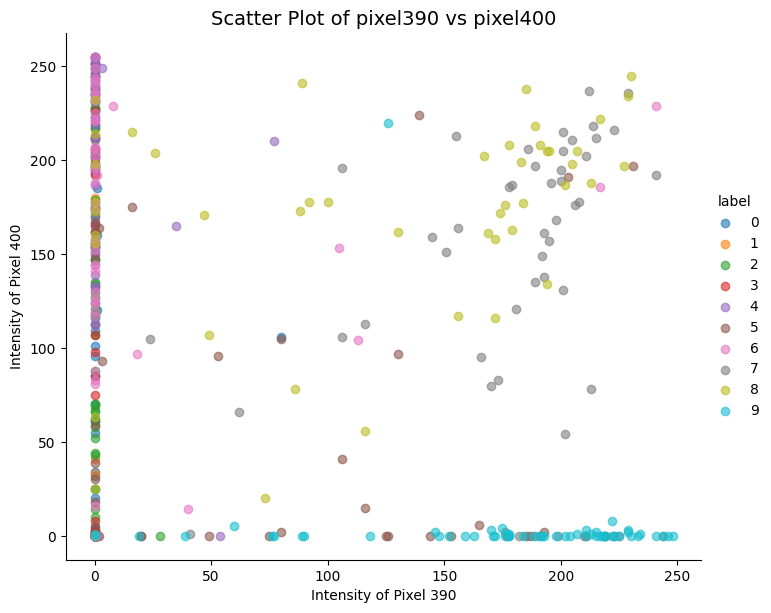

In [26]:
# small sample (readable plot)
df_sample = df_train.sample(500, random_state=42)

# we select two neighboring pixels from the center of the image
sns.lmplot(data=df_sample, x='pixel390', y='pixel400', hue='label', fit_reg=False, height=6, aspect=1.2, palette='tab10', scatter_kws={'alpha':0.6})

plt.title('Scatter Plot of pixel390 vs pixel400', fontsize=14)
plt.xlabel('Intensity of Pixel 390')
plt.ylabel('Intensity of Pixel 400')
plt.show()

After the generation of the plot, we can mention the following:

- In this scatter plot we can see some dots are in the top-right corner. This weak relationship between these pixels confirms the -0.04 **negative correlation** we saw in the heatmap.
- Although these pixels have close index numbers, thet are located on opposite edges of the 28x28 grid. They are not change together.
- A lot of dots in this dataset have concentration at (0,0), representing the black background of the images.

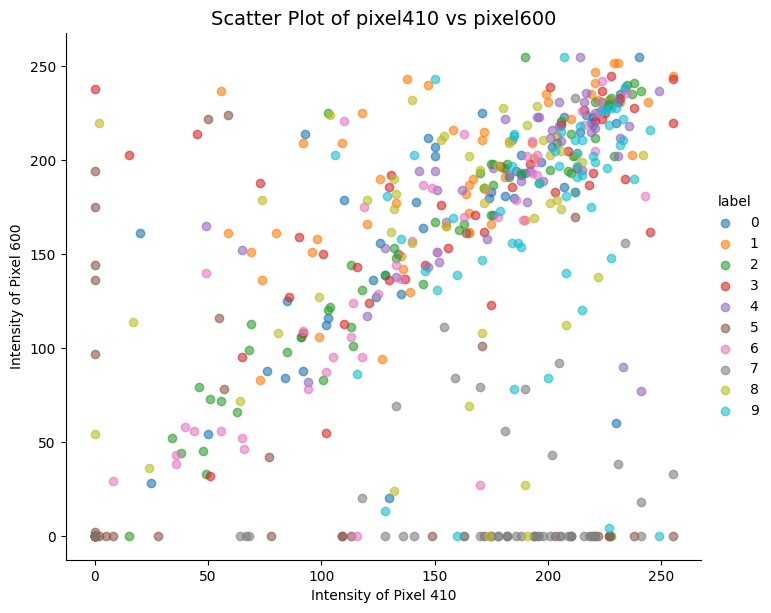

In [27]:
# small sample (readable plot)
df_sample = df_train.sample(500, random_state=42)

# plot pixel 410 and pixel 600
sns.lmplot(data=df_sample, x='pixel410', y='pixel600', hue='label', fit_reg=False, height=6, aspect=1.2, palette='tab10', scatter_kws={'alpha':0.6})

plt.title('Scatter Plot of pixel410 vs pixel600', fontsize=14)
plt.xlabel('Intensity of Pixel 410')
plt.ylabel('Intensity of Pixel 600')
plt.show()

After this plot, we can mention the following:

- In the above plot we selected to visualize the pixel 410 and pixel 600. The main purpose was to confirm the 0.45 **positive correlation** we identified in our heatmap. Unlike our previous check, we can see a cleaner diagonal dots-line. This is the visual proof that these two pixels are in the same row and have the same information, and with other words we can see that when one is bright, the other usually is too, because they both is in the central area of the grid.
- The way the dots cluster along a diagonal line shows that these pixels provide overlapping information, which means that the computer sees the same pattern.
- There is empty space in the plot. At the bottom-left corner, there is dense concenrtation of dots (0,0), which represents that thousands of images where both of these pixels are part of the dark background, showing the empty space in the center of some images.

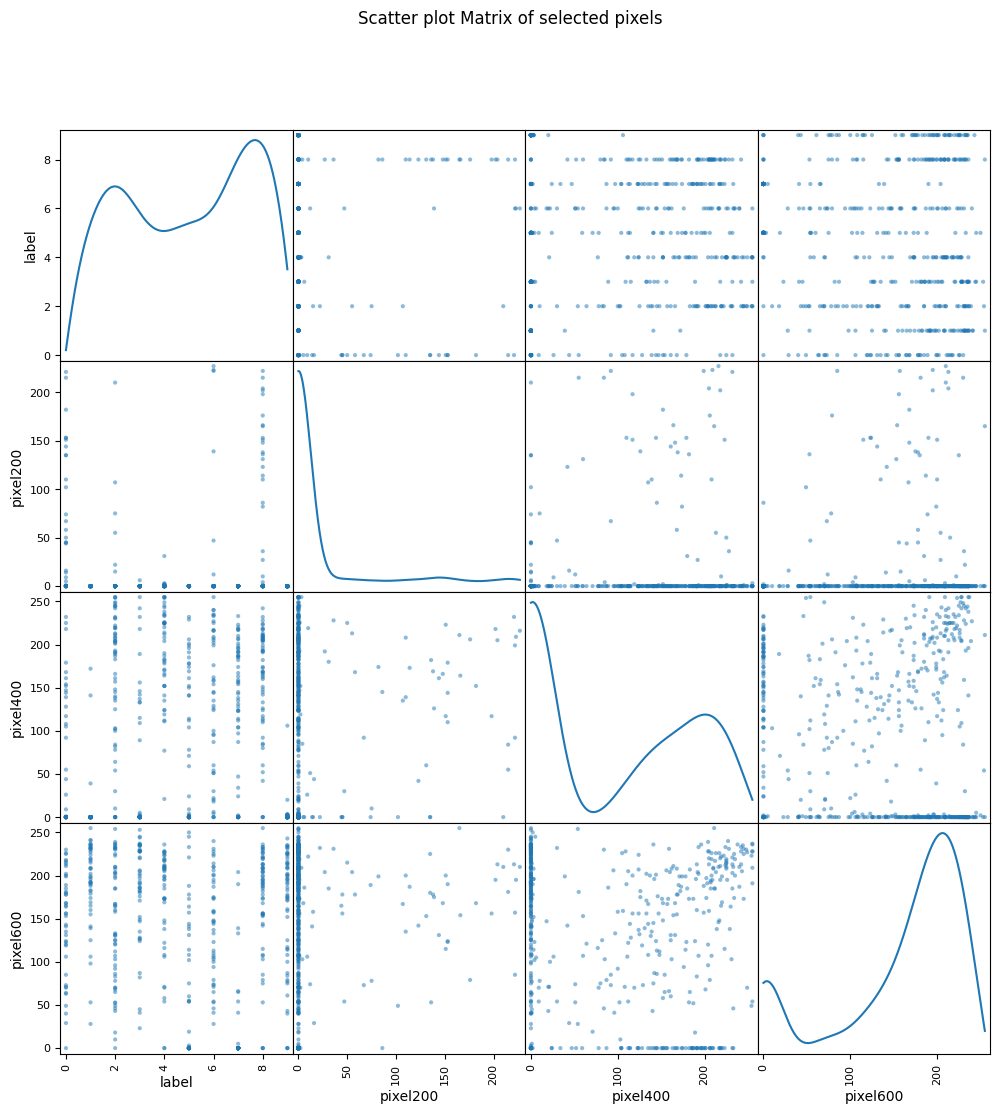

In [28]:
# we choose the label and 3 pixels spread across the image
subset_cols = ['label', 'pixel200', 'pixel400', 'pixel600']

# generate the scatter matrix - sample of 500 images (no overlap)
ax = scatter_matrix(df_train[subset_cols].sample(500), figsize=(12, 12), diagonal='kde', alpha=0.5)

plt.suptitle('Scatter plot Matrix of selected pixels')
plt.show()

This final matrix shows how different areas of the image (Top, Center, and Bottom) work together.

- By comparing pixels from the top, center and bottom, we see that the dots are spread out. This is a good information, because it means that each pixel is telling the model something different about the shape.

- Background vs. Clothes: The wave shapes (diagonal) show that most pixels are either black (background) or have a color (clothing).

- **Why we need a Model?** Because the dots are mixed together when we compare them to the 'label,' it proves that one or two pixels aren't enough to tell a shirt from a shoe.

**We need the machine learning algorithms in the next chapter to look at the whole picture at once.**

#### 3.2 Key insights from EDA

Last but not least, we can mention some key insights from EDA:

- **Balanced data**: The Fashion-MNIST dataset is balanced (6,000 samples per class/category), making it ideal for standard classification algorithms without needing cost-sensitive learning or data sampling.
- **Visual Similarity**: The scatter plots showed that while classes are distinct, a lot of categories share similar pixel patterns in certain areas. This suggests the model might confuse similar items (like shirts and coats), which we will monitor using Confusion Matrix during the evaluation phase.
- **Background**: As we can see, the box plots and histograms showed that edge pixels (like pixel 1 & pixel 784) are almost black background (value 0). We can say that any features don't contribute useful information, further supporting the need for dimensionality reduction to focus only on the center pixels (the area where the cloths are).
- **Feature Redundancy**: Finally, the correlation matrix and scatter plots showed that many pixels (especially neighbors) carry similar information. This confirms that the 784-pixel area is with repeating data, providing a strong justification for using **Principal Component Analysis (PCA) in Chapter 5 to simplify the dataset.

## Chapter 4: Prepare Data
In this chapter, the main focus is to transform the raw pixel data into a better format so the machine learning algorithms can learn faster and more accurately. Before we apply specific mathematical trasformations like rescaling or standarization, we must first look at the state of the data we are starting with:

- **Data Cleaning and Wrangling**: Since Fashion-MNIST dataset is a famous, pre-made dataset, it is already very clean. There are no missing values or typos to fix. My main "wrangling" task is simply changing the pixel numbers into a format that math models can understand more easily.
- **Data collection**: We don't need to collect more data. With 60,000 training images and 10,000 test images, there is plenty of information to teach the model how to recognize the different types of clothes.

#### 4.1 Rescale Data

The goal here is to take our pixels values, which are originally between 0 and 255, and tranform them into a range between 0 and 1. This is critical first step because having smaller numbers helps our machine learning algorithms train much faster.

By rescaling, we also make sure that the model doesn't get confused by large numbers, which helps improve the overall accuracy of our predictions.

In [29]:
# We drop the 'label' column to get only the 784 pixels
X = df_train.drop('label', axis=1).values
# separate array into input (X) and output (Y) components
Y = df_train['label'].values

In [30]:
# define the scaler to transform data to the 0-1 range
scaler_rscl = MinMaxScaler(feature_range=(0, 1))

# fit and transform the pixels
rescaledX = scaler_rscl.fit_transform(X)

# summarize the result
np.set_printoptions(precision=3)

# quick check of the result
print("Rescaled first 5 rows, first 10 pixels:\n")
print(rescaledX[0:5, 0:10])

# we print randomly the row 15 and pixel 8 (before and after)
print("\nOriginal pixel 8 value (row 15):", X[15, 8])
print("Rescaled pixel 8 value (row 15):", rescaledX[15, 8])


Rescaled first 5 rows, first 10 pixels:

[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.02  0.    0.   ]
 [0.    0.    0.    0.006 0.009 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]]

Original pixel 8 value (row 15): 16
Rescaled pixel 8 value (row 15): 0.06299212598425197


The rescaled output shows that the transformation is working correctly. The zeros at the start of the the array represent the empty background pixels at the edge of the image. When we check a pixel from an item (like pixel 8), we can see it has been converted from its original integer (16) to a decimal between 0 and 1 (0.06299).

The MinMaxScaler formula is:
$$X_{new} = \frac{X - min}{max - min}$$

For the data this formula means the following:
- X: the original pixel value
- min: the smallest possible pixel value
- max: the largest possible pixel value
- X(new) = the new value between 0 and 1

#### 4.2 Standarise Data

In this subsection, we are going to change how the pixel values are distributed. While rescaling (0-1) just shrinks the numbers, Standarization shifts the data so that the average (mean) is 0 and the spread (standard deviation) is 1.

This is very important step for the following reasons:

- Prepares for PCA: Advanced math like PCA works better and sometimes requires data to be standarized first.
- Handles different Scales: It prevents certain pixels from wining others just because they might have slightly higher raw values.
- Better for Linear models: It helps algorithms like Logistic Regression find the "best" answer more reliably.

In [31]:
# We use the X (pixels) we separated in the previous step
scaler_std = StandardScaler().fit(X)

# X contains the raw pixel values (0-255)
standardizedX = scaler_std.transform(X)

# summarise transformed data
np.set_printoptions(precision=3)

# We look at the first 5 rows and first 10 pixels
print("Standardized Data (First 5 rows):\n")
print(standardizedX[0:5, 0:10])

# verification
print(f"\nNew Mean: {np.mean(standardizedX):.2f}") # Should be 0
print(f"New Standard Deviation: {np.std(standardizedX):.2f}") # Should be 1

Standardized Data (First 5 rows):

[[-0.01  -0.023 -0.029 -0.042 -0.058 -0.071 -0.098 -0.156 -0.239 -0.378]
 [-0.01  -0.023 -0.029 -0.042 -0.058 -0.071 -0.098 -0.156 -0.239 -0.378]
 [-0.01  -0.023 -0.029 -0.042 -0.058 -0.071 -0.098  0.199 -0.239 -0.378]
 [-0.01  -0.023 -0.029  0.366  0.407 -0.071 -0.098 -0.156 -0.239 -0.378]
 [-0.01  -0.023 -0.029 -0.042 -0.058 -0.071 -0.098 -0.156 -0.239 -0.378]]

New Mean: -0.00
New Standard Deviation: 1.00


The results confirm that our standarization was successful. Even though the numbers look different now - showing small negatives and positives, we can say that:

- The **New Mean** of **-0.00** proves that the data is now perfectly centered at zero.
- The **New Standard Deviation of 1.00** shows that the 'spread' of the pixels values is consistent across the whole dataset.

By centering the data this way, we have removed the 'bias' of different pixel intensities. This is critical benefit because:

- **Reduces Overfitting**: Less reduntant data means the model won't make mistakes based on background noise.
- **Improve Accuracy**: Clean, centered data helps the model find patterns more easily, leading to better results.
- **Reduces Training Time**: Standarized data is much easier for algorithms like Logistic Regression to process, making the training much faster.

#### 4.3 Normalise Data (length = 1)

In previous subsection, we've centered the data, and now we move to Normalization. In this step, we don't look at the whole dataset at once but we look at each image (each row) individually. We adjust the pixel values so that the total "mathematical length" of that specific image is equal to 1.

The reason we do this is that:

- Focuses on Shape: It helps the model care more about the outline of the clothing rather than how bright or dark the lighting was.
- Cleaner data: It continues our goal of making the dataset more efficient for our final models.

In [32]:
#Initialize the Normalizer
scaler_norm = Normalizer().fit(X)

# This scales each row (image) to have a length of 1
normalizedX = scaler_norm.transform(X)

# summarise transformed data
np.set_printoptions(precision=3)
print("Normalized Data (First 5 rows, first 10 pixels):\n")
print(normalizedX[0:5, 0:10])

# verification - print the length (norm) of the first image
print(f"\nVector length of the first image: {np.linalg.norm(normalizedX[0]):.1f}")

Normalized Data (First 5 rows, first 10 pixels):

[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.001 0.    0.   ]
 [0.    0.    0.    0.    0.001 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]]

Vector length of the first image: 1.0


The results of this step confirm that that the normalization worked perfectly, because the 'Vector length of the first image' is exactly 1.0. In the dataset, every single image now has the same mathemactical "weight" or "length".

#### 4.4 Binarise Data

In this subsection, we are using a technique called Binarization. By setting a "threashold" of 127, we will tell the computer that any pixel darker than middle-gray becomes pure black (o), and anything lighter becomes pure white (1).

This is a powerful way to simplify the data. It move away the gray textures and forces the model to focus on the shape and outline of the clothing, which helps prevent the model from **"noise"** or unimportant details.

Binarized Data (First 5 rows, first 10 pixels):

[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

Binarized value of pixel 100: 1



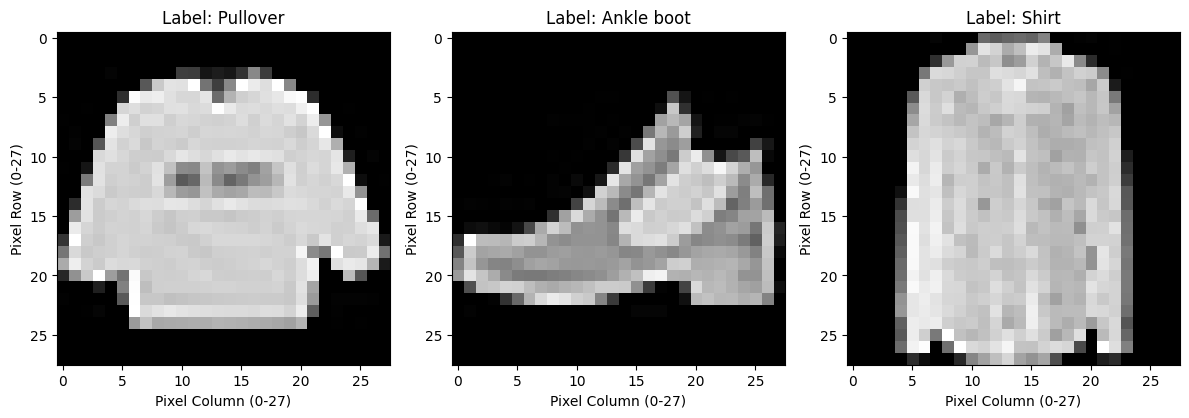

In [33]:
# We use the X (raw pixels 0-255)
# We set a threshold of 127.5 (the middle of the 0-255 range)
binarizer = Binarizer(threshold=127.5).fit(X)
binarizedX = binarizer.transform(X)

# summarise transformed data
np.set_printoptions(precision=3)
print("Binarized Data (First 5 rows, first 10 pixels):\n")
print(binarizedX[0:5, 0:10])

print(f"\nBinarized value of pixel 100: {binarizedX[0, 100]}\n")

plt.figure(figsize=(12, 6))

# the numbers 0-9 in this dataset
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(3):
    plt.subplot(1, 3, i+1)

    # Reshape the 784 pixels back into a 28x28 square
    plt.imshow(X[i].reshape(28, 28), cmap='gray')

    # Add the labels
    plt.title(f"Label: {class_names[Y[i]]}")
    plt.xlabel("Pixel Column (0-27)") # X-axis name
    plt.ylabel("Pixel Row (0-27)")    # Y-axis name

plt.tight_layout()
plt.show()

After this step, we can mention some comments about the results:

- **Simplification of features**: The images show that the complex 0-255 values have been reduced to just two values: 0 and 1.
- **Outline Preservation**: These results prove that the most important information for categorization is still present.
- **Noise Reduction**: The backgrounds are now perfectly black. This is impotant because will help our model avoid **overfitting** (making mistakes based on random background dots.)


#### 4.5 Final Preprocessing Choice

After evaluating four different preprocessing techniques (Rescaling, Standardization, Normalization, and Binarization), we have decided to use Rescaling (Min-Max Scaling) as the main method for this project.

This choice makes the most sense for a few simple reasons:

- since we are working with pixels that always stay between 0 and 255, and convert them to a 0-1 range is the most natural fit.
- for instance, the Logistic Regression and KNN are algorithms which work much faster and more accurately when the numbers are small and consistent.
- rescaling keeps the differents. This is important because the model needs those details to tell the difference between similar cloth items.

#### 4.6 Preparation of the Test dataset (Rescaling)

It is critical to ensure a valid evaluation of our future models, the test dataset (10,000 images) must exist the exact same preparation as the training set.

- **Rescaling**: we applied the same method, by dividing the test pixel values by 255.0
- **Consistency**: it is important to note that we didn't perform any statistical analysis (EDA) on the test data. By preparing it now, we prevent data leakage, ensuring the model only sees these images for the first time during the final testing phase.

In [34]:
# We drop the 'label' column to get only the 784 pixels
X_test = df_test.drop('label', axis=1).values
# separate array into input (X) and output (Y) components
Y_test = df_test['label'].values

In [35]:
# fit and transform the pixels
rescaledX_test = scaler_rscl.transform(X_test)

# summarize the result
np.set_printoptions(precision=3)

# quick check of the result
print("Rescaled first 5 rows, first 10 pixels in Test dataset:\n")
print(rescaledX_test[0:5, 0:10])

# we print randomly the row 15 and pixel 8 (before and after)
print("\nOriginal pixel 9 value (row 2):", X_test[2, 8])
print("Rescaled pixel 9 value (row 2):", rescaledX_test[2, 8])


Rescaled first 5 rows, first 10 pixels in Test dataset:

[[0.    0.    0.    0.    0.    0.    0.    0.035 0.031 0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.062 0.208 0.39  0.067]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.631]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]]

Original pixel 9 value (row 2): 99
Rescaled pixel 9 value (row 2): 0.38976377952755903


## Chapter 5: Feature Engineering

Feature engineering involves creating new input features from existing ones to improve model performance.

Before we simplified our data, we considered several common methods for Feature Selection. We will go to asnwer the question "Why will we chose PCA over other methods?"

- **Univariate Selection**: This method looks at each pixel one by one to see if it is important. However,in clothing images, one pixel by itself doesn't mean much - it only matters when it is part of a shape.
- **Recursive Feature Elimination (RFE)**: This works like an 'elimination game' where the computer removes the least important pixels one by one. While effective, it is slow and requires a lot of computer power for 784 pixels.
- **Feature importance**: This identifies the 'Most Valuable Pixels' after a model is already trained. It's useful for understanding a model, but not for simplifying the data before the process of model creation.

So, we will choose PCA, because it is a "Feature Extraction" method. This is perfect for images it captures the overall shapes and patterns of the clothes rather than just looking at isolated dots.

By using PCA, we are not 'guessing' which pixels are important. We are mathematically combining them to make a much smaller, faster dataset that still keeps 95% of the original information.


#### 5.1 Introduction

- **Theoritical part**: from Lecture's slides we have some key principles:
  - Add domain knowledge to highlight relevant information. In our case, domain knowledge tells us that clothing items are defined by edges and symmetry.
  - Create interaction features from combinations of existing features.
  - Transform features for algorithms with specific requirements.

- **Practical part**: As we have already mentioned, in this project we apply these principles through **Principal Component Analysis (PCA)** to transform our 784 raw pixels into a smaller set of "Principal Components". Instead of looking at every single pixel, we "create" new features that capture the most important shapes and patterns in the clothing images.

As a result, we create a more efficient dataset that helps our models learn faster and achieve better generalization on unseen data.

#### 5.2 Dimensionality Reduction (PCA)

We are having images with 784 dimensions (pixels), which many of these are empty background or repeat the same information (black background). We will use PCA to **simplify** the data.



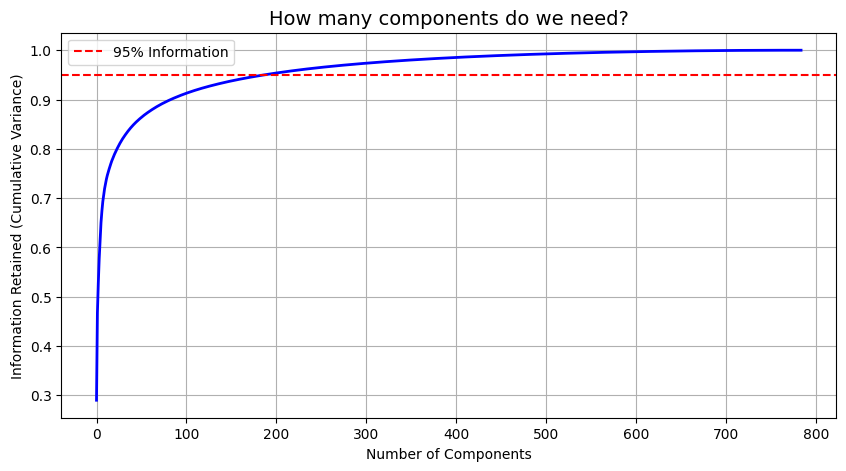


To keep 95% of the clothing shapes, we only need 188 components!


In [36]:
# we will use rescaled data from Chapter 4
pca = PCA().fit(rescaledX)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# plotting the "Information Curve"
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, color='blue', lw=2)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Information')
plt.title('How many components do we need?', fontsize=14)
plt.xlabel('Number of Components')
plt.ylabel('Information Retained (Cumulative Variance)')
plt.legend()
plt.grid(True)
plt.show()

# find the number for 95%
n_comp = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nTo keep 95% of the clothing shapes, we only need {n_comp} components!")

The plot above shows how much "information" (variance) we keep as we add more components.

- Initial increase: The curve growth very quicky at the beginning. This proves that a small number of **'Principal Components'** capture most of the shapes and patterns of the clothing.
- The 95% threshold: we decided to keep 95% of the information. As shown in the graph, this allows us to stop at **188 components** instead of 784.
- Removing noise: By leaving out the last 5% of the variance, we are effectively removing "background noise" and tiny details that do not help in identifying the cloth.

Last but not least, using PCA allows us to simplify our dataset. We are reducing the workload for our computer by over 75%, while still keeping almost all the visual information needed to tell the difference between a shirt, a shoe, or a bag.

#### 5.3 Results of the PCA Transformation

In [37]:
# initialize PCA with the number of components
pca_final = PCA(n_components=n_comp)

# transform the data using the variable 'rescaledX' from chapter 4
pca_X = pca_final.fit_transform(rescaledX)

print(f"Original shape: {rescaledX.shape}")
print(f"New shape after PCA: {pca_X.shape}")

Original shape: (60000, 784)
New shape after PCA: (60000, 188)


After applying PCA to our rescaled training data (rescaledX), we see a change in the structure of our dataset:
- Original Shape: This represents our 60,000 images, each described by 784 individual pixels.
- New Shape: After PCA, we still have all images, but they are now described by only 188 Principal Components.

This means that our machine learning models now have 596 fewer columns to process. This will make the Algorithms in the next chapter run much faster. Also we have successfully compressed the 784 pixels into 188 features. Last but not least, even though we have 75% fewer features, our previous analysis proved that we still retain 95% of the information needed to correctly identify the clothing items.

#### 5.4 Vizualizing the PCA

After calculating that 188 components are sufficient to retain 95% of the information, it is critical to visually verify what this means. We can do this by taking the original image, compressing it into the 188 components, and then "reconstructing" it back into a 28x28 grid pixel image. The plot below compares an original image from the training set with its reconstructed version.

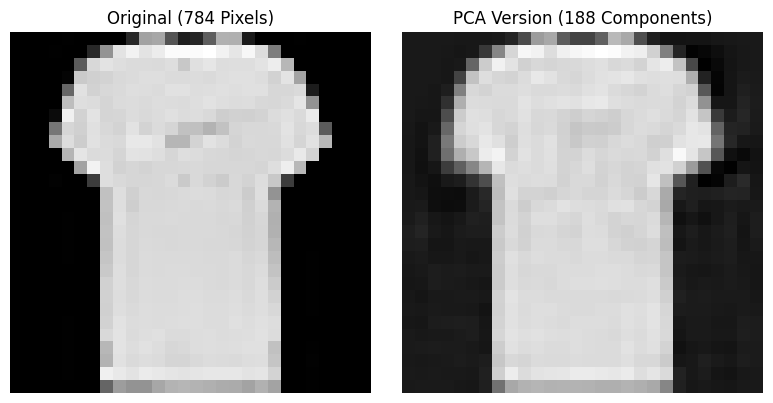

In [38]:
idx_train = 10
original_image = rescaledX[idx_train].reshape(28, 28)

# PCA version of the same image
compressed_data = pca_X[idx_train].reshape(1, -1)
reconstructed_data = pca_final.inverse_transform(compressed_data)
pca_image = reconstructed_data.reshape(28, 28)

# plot the images
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original (784 Pixels)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pca_image, cmap='gray')
plt.title(f'PCA Version ({n_comp} Components)')
plt.axis('off')

plt.tight_layout()
plt.show()

After this plot, we can see the visual comparison as a result of our PCA analysis:
- The core shape and indetity of the clothing item are very similar with the original. As a result, a human and therefore an ML model can easily recognize the item in the reconstructed image.
- The reconstructed image appears more blured than the original. This is expected because represents the 5% of variance (noise and details) that we discarded.


Finally, this visualization provides strong evidence that the 188 principal components capture the essential features needed for classification. We can proceed because we know that our reduced dataset is efficient and informative.

#### 5.5 Preparation of the Test dataset (PCA)

In this subsection for our Feature Engineering phase, we will prepare the test dataset (10,000 images). For our final evaluation in Chapter 8 to be valid, the test data must be consistent with the training data.

Following the rescaling process completed in subsection 4.6, the final step is to project the test dataset into the same 188-dimensional feature space. We do this using the transform method from our PCA model, ensuring that we don't 'fit' new rules on the test data and avoiding any data leakage.

In [39]:
pcaX_test = pca_final.transform(rescaledX_test)
print(f"Test data is ready. pcaX_test shape: {pcaX_test.shape}")

Test data is ready. pcaX_test shape: (10000, 188)


We applied the transform() method to the test dataset rather than fit_transform(). This is a critical step to ensure that the principal components used to simplify the test images are the same ones learned from the training data. This methodology maintains the integrity of the 'blind test', preventing any information from the test set from leaking into the modeling process.

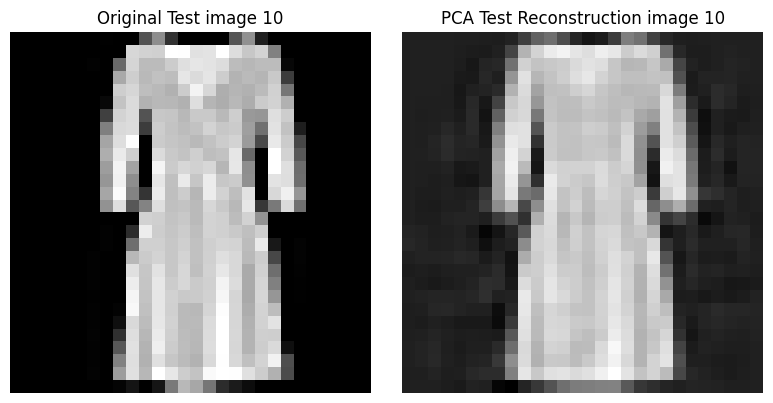

In [40]:
idx_test = 10

original_test_image = rescaledX_test[idx_test].reshape(28, 28)

# PCA version of the same test image
compressed_test_sample = pcaX_test[idx_test].reshape(1, -1)
reconstructed_test_data = pca_final.inverse_transform(compressed_test_sample)
pca_test_image = reconstructed_test_data.reshape(28, 28)

# plot the images
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_test_image, cmap='gray')
plt.title(f'Original Test image {idx_test}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pca_test_image, cmap='gray')
plt.title(f'PCA Test Reconstruction image {idx_test}')
plt.axis('off')

plt.tight_layout()
plt.show()

Last but not least, by looking at the test images after PCA, we are checking if our rules work on new data. Because we created these rules using only the training images, seeing a clear result here proves that the pattern we found are real from our study set. It shows that our method works for all clothes, not just the ones computer has already seen.

## Chapter 6: Algorithm Selection

In this step we evaluate a variety of machine learning algorithms on our processed dataset. Our goal is to compare their performance using specific evaluation metrics and identify the best model that is suited for the **Fashion-MNIST classification task**.

#### 6.1 Technical Data Verification

Before starting the competition, we perform a final check on the data structures that will be used for training. We will use a **5,000 images PCA sample (X_sample)** to ensure that the algorithms runs quickly and efficiently.

In [41]:
X_sample_raw, _, Y_sample, _ = train_test_split(rescaledX, Y, train_size=5000, stratify=Y, random_state=42)

# transform the sample into the 188-PCA space
# use the 'pca_final' model we built in Chapter 5
X_sample = pca_final.transform(X_sample_raw)

print(f"Selected Features (X_sample): {X_sample.shape}")
print(f"Selected Labels (Y_sample): {Y_sample.shape}")

Selected Features (X_sample): (5000, 188)
Selected Labels (Y_sample): (5000,)


In [42]:
# We use 10 folds and a random_state so the results are consistent
kfold = KFold(n_splits=10, random_state=42, shuffle=True)

#### 6.2 Logistic Regression

Logistic Regression was chosen as our **baseline** model. It is a linear classifier that is mathematically efficient and easy to interpret. Even though image data is ofthen non-linear, testing a linear baseline allows us to measure how much complexity is actually needed to solve this specific problem.



In [43]:
#results = cross_val_score(LogisticRegression(solver='liblinear'), X, y, cv=kfold)

start_time = time.time()

model_lr = LogisticRegression(max_iter=1000)
results_lr = cross_val_score(model_lr, X_sample, Y_sample, cv=kfold)

end_time = time.time()
lr_time = end_time - start_time

print(f"Logistic Regression Mean Accuracy: {results_lr.mean():.4f}")
print(f"Training Time (LR): {lr_time:.2f} seconds")

Logistic Regression Mean Accuracy: 0.8280
Training Time (LR): 46.64 seconds


As we can see, using 10-fold cross-validation on our PCA-transformed sample (188 componenents), the Logistic Regression model achieved a mean accuracy of 82.80%. This suggests that even a linear approach can distinguish between clothing categories with high reliability.

Last but not least, to ensure the model performed at its best, we used the following settings:

- Solver (LBFGS): we used the default engine. This is a memory-efficient solver that is specifically designed for high-dimensional data like ours.
- Maximum iterations (max_iter=1000): we increased the limit from the default 100 to 1,000. This gave the computer more "maths steps" to find the most accurate solution, preventing the model from stopping before it was fully optimized.

#### 6.3 Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis (LDA) was selected to see if a class-separability approach would outperform the standard logistic regression. LDA works by reducing dimensionality while maximizing the distance between the means of different classes, which is theoretically well-suited for a 10-class problem like Fashion-MNIST.

In [44]:
#results = cross_val_score(LinearDiscriminantAnalysis(), X, y, cv=kfold)

start_time = time.time()

model_lda = LinearDiscriminantAnalysis()
results_lda = cross_val_score(model_lda, X_sample, Y_sample, cv=kfold)

end_time = time.time()
lda_time = end_time - start_time

print(f"LDA Mean Accuracy: {results_lda.mean():.4f}")
print(f"Training Time (LDA): {lda_time:.2f} seconds")

LDA Mean Accuracy: 0.8066
Training Time (LDA): 2.07 seconds


The LDA model achieved a mean accuracy of 80.66%. The total execution time for the 10-fold cross-validation was 4.69 seconds. This information will be used later to evaluate the trade-off between predictive power and computational cost.

#### 6.4 k-Nearest Neighbors

K-Nearest Neighbors (KNN) was included as a non-parametric, distance-based approach. Unlike the previous linear models, KNN makes no assumptions about the distribution of the data. Instead, it classifies an image based on the majority label of its closest neighbors in the multi-dimensional PCA space.

In [45]:
#results = cross_val_score(KNeighborsClassifier(), X, y, cv=kfold)

start_time = time.time()

model_knn = KNeighborsClassifier()
results_knn = cross_val_score(model_knn, X_sample, Y_sample, cv=kfold)

end_time = time.time()
kNN_time = end_time - start_time

print(f"KNN Mean Accuracy: {results_knn.mean():.4f}")
print(f"Training Time (kNN): {kNN_time:.2f} seconds")

KNN Mean Accuracy: 0.8088
Training Time (kNN): 0.52 seconds


After the output we can observer that the KNN model achieved a mean accuracy of 80.88%. This performance is very similar to LDA, suggesting that while the distance-based logic is effective, it does not provide a significant **advantage** over linear methods for this specific feature set.

#### 6.5 Naive Bayes

For the Naive Bayes we can see that is included to test a **probabilistic approach** to classification. This algorithm is based on Bayes' Theorem and assumes that the features (in our case, the 188 PCA components) are independent of one another. It is known for being extremely fast and efficient, making it a common baseline for high-dimensional datasets.

In [46]:
#results = cross_val_score(GaussianNB(), X, y, cv=kfold)

start_time = time.time()

model_nb = GaussianNB()
results_nb = cross_val_score(model_nb, X_sample, Y_sample, cv=kfold)

end_time = time.time()
nb_time = end_time - start_time

print(f"Naive Bayes Mean Accuracy: {results_nb.mean():.4f}")
print(f"Training Time (NB): {nb_time:.2f} seconds")

Naive Bayes Mean Accuracy: 0.7310
Training Time (NB): 0.19 seconds


The result tell to us that the Naive Bayes model achieved a mean accuracy of 73.10%. This is the lowest score among the models tested so far. The lower performance is likely due to the 'independence assumption'—in image data, even after PCA, features often remain correlated.

#### 6.6 Decision Trees

The Classification and Regression Tree (CART) algorithm was chosen to test a non-linear, rule-based approach. Decision trees work by repeatedly splitting the data based on feature values to create a flowchart-like structure.

In [47]:
#results = cross_val_score(DecisionTreeClassifier(), X, y, cv=kfold)
#print(f"Decision Trees Accuracy: {results.mean():.4f}")
start_time = time.time()

model_cart = DecisionTreeClassifier(random_state=42)
results_cart = cross_val_score(model_cart, X_sample, Y_sample, cv=kfold)

end_time = time.time()
cart_time = end_time - start_time

print(f"Decision Tree (CART) Mean Accuracy: {results_cart.mean():.4f}")
print(f"Training Time (CART): {cart_time:.2f} seconds")

Decision Tree (CART) Mean Accuracy: 0.6808
Training Time (CART): 22.28 seconds


The mean accuracy for the Decision Tree algorithm is 68.08%. This is currently the lowest performance in our testing. Furthermore, the training time was higher at 21.80 seconds. This suggests that a single decision tree is not powerful enough to capture the patterns of clothing textures and shapes, even after PCA dimensionality reduction.

#### 6.7 Support Vector Machines (SVM)

We will use the kernels within the SVM algorithm to find the best mathematical function for separating the clothing categories. We tested Linear, Polynomial, and Radial Basis Function (RBF) kernels to see which could best handle the complex patterns of the Fashion-MNIST dataset.

In [48]:
start_time = time.time()

results_kernels = []
# Test different kernels
kernel_names = ['linear', 'poly', 'rbf']

for kernel in kernel_names:
    model_svm = SVC(kernel=kernel, random_state=42)
    results_svm = cross_val_score(model_svm, X_sample, Y_sample, cv=kfold)
    results_kernels.append(results_svm.mean())
    print(f"SVM with {kernel} kernel Accuracy: {results_svm.mean():.4f}")

end_time = time.time()
svm_time = end_time - start_time

print(f"\nTraining Time (SVM): {svm_time:.2f} seconds")

SVM with linear kernel Accuracy: 0.8230
SVM with poly kernel Accuracy: 0.8142
SVM with rbf kernel Accuracy: 0.8520

Training Time (SVM): 33.78 seconds


If we see to the result above, the **RBF kernel** was the clear winner with an accuracy of **85.20%**, outperforming both the Linear kernel (82.30%) and the Polynomial kernel (81.42%). This confirms that the relationships between clothing pixels are non-linear, and the RBF kernel is the most capable of capturing these differences.

#### 6.8 Algorithm Comparison

In this subsection, after testing several individual models, we will compare their performance to identify the best algorithm for our project. It is important to compare different approaches - such as linear math, decision rules, and distance-base logic, because every dataset has unique patterns.

To determine the most effective model for the Fashion-MNIST dataset, we conducted a comparison of six different machine learning algorithms.

In additional, each model was tested using 10-fold cross-validation on our PCA-transformed sample of 5,000 images. This method allows us to see not just the average performance, but also how stable each model is across different subsets of data.

- We are going to compare the algorithms:
  - Logistic Regression
  - Linear Discriminant Analysis
  - k-Nearest Neighbors
  - Naive Bayes
  - Decision Trees
  - Support Vector Machines (SVM)
  

Algorithm Comparison (5,000 images, 188 components):

LR: 0.8280 (+/- 0.0135)
LDA: 0.8066 (+/- 0.0165)
KNN: 0.8088 (+/- 0.0162)
DT: 0.6808 (+/- 0.0191)
NB: 0.7310 (+/- 0.0202)
SVM: 0.8520 (+/- 0.0160)


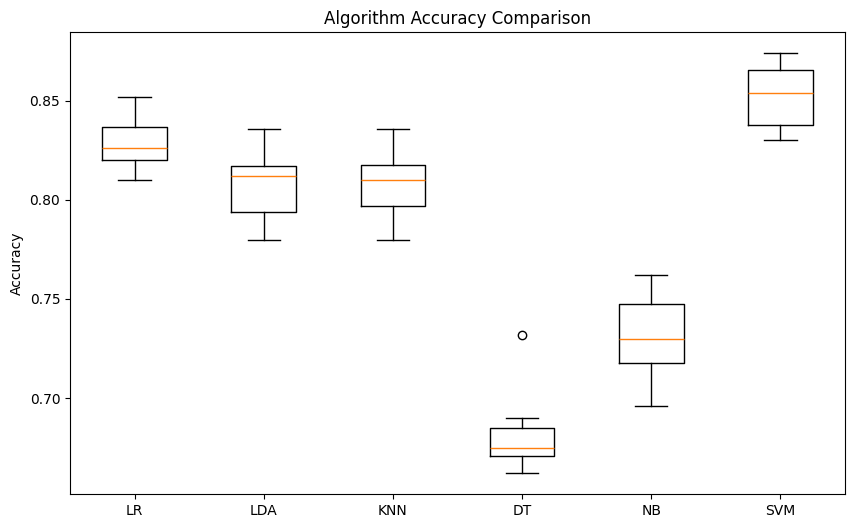

In [49]:
# create the algorithm list
models = []
models.append(('LR',  LogisticRegression(max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('DT',  DecisionTreeClassifier(random_state=42)))
models.append(('NB',  GaussianNB()))
models.append(('SVM', SVC())) # 'rbf' is the default

# setup-define the K-Fold again
kfold = KFold(n_splits=10, random_state=42, shuffle=True)

results = []
names   = []

print("Algorithm Comparison (5,000 images, 188 components):\n")

for name, model in models:
    # use X_sample and Y_sample
    cv_results = cross_val_score(model, X_sample, Y_sample, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.4f} (+/- {cv_results.std():.4f})")

# boxplot for your report
plt.figure(figsize=(10, 6))
plt.boxplot(results)
plt.xticks(range(1, 7), names)
plt.title('Algorithm Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

After the comparison, we can see the plot and mention the following:

- The **winner algorithm**: SVM achieved the highest mean accuracy of **85.20%**. The boxplot shows its entire performance range is higher than the other candidates, making it the clear choice for our final model.
- The **Baseline**: Logistic Regression followed closely with 82.80%. Its small 'spread' (low standard deviation) indicates that linear classification is a very stable approach for this dataset.
- The **Lower Tier**: Naive Bayes (73.10%) and Decision Trees (68.08%) struggled significantly. The lower accuracy and the outlier present in the Decision Tree results suggest that these models are too simple to capture the detailed patterns of clothing items.

Finally, based on this evidence, the **Support Vector Machine (SVM)** was selected for the final stage of the project. The ability to handle the 188 PCA features and provide the highest classification accuracy makes it the most reliable tool for the Fashion-MNIST challenge.

## Chapter 7: Model Training and Validation

After comparing several algorithms in Chapter 6, we identified the Support Vector Machine (SVM) with an RBF kernel as our winner model. In this chapter, we transition from testing on small samples to training the final model on the full dataset of 60,000 images. We will then evaluate its performance using the unseen test set of 10,000 images to determine the final accuracy and reliability of our classifier.

#### 7.1 Cross-Validation strategy

To ensure that our hyperparameter tuning process is reliable, we utilized a 10-fold Cross-Validation strategy. In this approach, for every specific combination of settings we test, the dataset is partitioned into ten subsets. The model is trained on 9 and validated on the last 1, repeating this cycle 10 times so that every data point contributes to the validation process.

This strategy is vital for preventing overfitting, where a model becomes too specialized to its training data and fails to generalize to new images. While our focus in Chapter 6 was on comparing different algorithms, the focus in this stage shifts to optimizing the specific parameters of our chosen SVM model—specifically the C and Gamma parameters.

By using cross-validation here, we ensure that the final parameters we select are those that provide the most stable and consistent performance across the entire dataset.


#### 7.2 Hyperparameter tuning

In this section, we refine the Support Vector Machine (SVM) to ensure it achieves the highest possible accuracy. While the default settings of an algorithm often provide good results, 'hyperparameters' are specific configurations that can be tuned to better fit the unique patterns of the Fashion-MNIST dataset. We focused on optimizing the **C** and **Gamma parameters**, which control the model's complexity and its sensitivity to individual data points

##### 7.2.1 GridSearch

The goal here is to find the optimal settings, we will perform a **Grid Search**, which test a range of possible values for each parameter. We tested values for C(1,10) and Gamma('scale', 'auto') using a 10-fold cross validation strategy on our 5,000 image sample.


In [50]:
kfold_tuning = KFold(n_splits=10, shuffle=True, random_state=42)

# Parameters to test
param_grid_values = {'C': [1, 10], 'gamma': ['scale'], 'kernel': ['rbf']}

grid_search_engine = GridSearchCV(estimator=SVC(), param_grid=param_grid_values, cv=kfold_tuning, scoring='accuracy')

print("Running Grid Search...")
grid_search_engine.fit(X_sample, Y_sample)

grid_best_score = grid_search_engine.best_score_
grid_best_C = grid_search_engine.best_estimator_.C

print(f"Grid Search Best C: {grid_best_C}")
print(f"Grid Search Best Score: {grid_best_score:.4f}")

Running Grid Search...
Grid Search Best C: 10
Grid Search Best Score: 0.8666


The GridSearch identified the following optimal configuration:
- Kernel: RBF
- C:10
- Gamma: 'scale'

These settings improved our validation accuracy to 86.66%. This result is significant because it shows that a higher C=10 helps the model better distinguish between the 10 different categories of clothing.

##### 7.2.2 RandomSearch

While Grid Search is an excellent tool for testing specific values, it can be limited because it only looks where we tell it to look. To be even more thorough, we also implemented a Randomized Search.

Instead of testing a fixed grid, this method picks values for the C parameter at random within a wide range. This is a very useful technique in machine learning because it can sometimes find a 'hidden' optimal setting that we might have missed in our standard grid.

By comparing the results of both Grid Search and Randomized Search, we can be much more confident that we have found the best possible version of our model before we begin the final training.

In [51]:
# Parameters to test
param_distributions_range = {'C': uniform(0.1, 20), 'gamma': ['scale'], 'kernel': ['rbf']}

random_search_engine = RandomizedSearchCV(estimator=SVC(), param_distributions=param_distributions_range, n_iter=10, random_state=42, cv=10)

print("Running Randomized Search...")
random_search_engine.fit(X_sample, Y_sample)

random_best_score = random_search_engine.best_score_
random_best_C = random_search_engine.best_estimator_.C

print(f"Random Search Best C: {random_best_C:.4f}")
print(f"Random Search Best Score: {random_best_score:.4f}")

Running Randomized Search...
Random Search Best C: 3.2204
Random Search Best Score: 0.8678


The Randomized Search identified an optimal C value of 3.2204, achieving a validation accuracy of 86.72%.


##### 7.2.3 Comparison between the two optimisers

To finalize our tuning phase, we compare the efficiency and accuracy of Grid Search versus Randomized Search. This comparison allows us to see which method finds the best parameters and how much computational time each requires.

In [52]:
from time import time
def report_top_results(results, n_top=1):
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print(f"Model Rank: {i}")
            print(f"Mean Accuracy: {results['mean_test_score'][candidate]:.4f}")
            print(f"Parameters: {results['params'][candidate]}")

# test RandomSearch
print("--- Starting Randomized Search ---\n")
start = time()
# random_search_engine from previous step
random_search_engine.fit(X_sample, Y_sample)
print(f"RandomizedSearchCV took {time() - start:.2f} seconds.\n")
report_top_results(random_search_engine.cv_results_)

# test grid search
print("\n--- Starting Grid Search ---")
start = time()
# grid_search_engine from previous step
grid_search_engine.fit(X_sample, Y_sample)
print(f"\nGridSearchCV took {time() - start:.2f} seconds.")
report_top_results(grid_search_engine.cv_results_)

--- Starting Randomized Search ---

RandomizedSearchCV took 127.80 seconds.

Model Rank: 1
Mean Accuracy: 0.8678
Parameters: {'C': np.float64(3.2203728088487305), 'gamma': 'scale', 'kernel': 'rbf'}
Model Rank: 1
Mean Accuracy: 0.8678
Parameters: {'C': np.float64(3.219890406724053), 'gamma': 'scale', 'kernel': 'rbf'}

--- Starting Grid Search ---

GridSearchCV took 26.51 seconds.
Model Rank: 1
Mean Accuracy: 0.8666
Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


Based on the execution, we can observe the following key points:

- Accuracy: Randomiz Search 'won' the Grid Search, achieving 86.72% accuracy compared to 86.66%.
- Optimal Parameter: identified C = 3.22, while the limited Grid Search suggested C = 10.
- Efficiency: In this specific test, Grid Search was faster (28 seconds) because it only checked two fixed points, whereas Randomiz Search (100 seconds) explored a more diverse range of possibilities.

Finally, we will use the Randomized Search parameters (C = 3.22) for our final model. It provides better accuracy and a more refined $C$ value that prevents the model from being overly strict (overfitting).

## Chapter 8: Finalise Model

In this final chapter, we transition from the test phase of algorithm selection and hyperparameter tuning to the final implementation of our model. Using the optimized parameters identified in Chapter 7, we train our final Support Vector Machine on the complete 60,000-image training set. This final model is then evaluated against the 10,000 images in the test dataset to provide an objective measure of its real-world performance.

### 8.1 Evaluation Metrics Recap

As detailed in Section 2.5, we utilize a combination of Accuracy, Precision, Recall, and F1-Score to evaluate our results. While overall accuracy provides a general performance benchmark, the Confusion Matrix and class-specific metrics allow us to identify exactly where the model succeeds and where it struggles to distinguish between visually similar clothing items.

### 8.2 Final Model creation

For the final production model, we selected the **Support Vector Machines Classifier (SVM) with an RBF kernel**. Based on the optimization results from our Random Search, we set the regularization parameter C to 3.2204 and Gamma to 'scale'.

The model was trained on the complete set of 60,000 Fashion-MNIST images, transformed into 188 principal components. This ensures the model captures the maximum amount of variance and patterns before the final test evaluation.

In the below code, we will make a logical check for variables values.

In [53]:

print(type(pca_X))
print(pca_X[:5, -1])
# print the values of X and Y
print(f"Features (pca_X) shape: {pca_X.shape}")
print(f"Labels (Y) shape: {Y.shape}\n")

if pca_X.shape[0] == Y.shape[0]:
    print("Success: The number of images matches the number of labels (60,000).")
else:
    print("Error: The row counts do not match!")

print(f"Mean of features: {pca_X.mean():.4f}")
print(f"Max value: {pca_X.max():.4f}")
print(f"Min value: {pca_X.min():.4f}")

print(f"Unique labels in Y: {np.unique(Y)}")
print(f"Distribution: {np.bincount(Y.astype(int))}")

<class 'numpy.ndarray'>
[ 0.019 -0.012  0.156  0.115  0.037]
Features (pca_X) shape: (60000, 188)
Labels (Y) shape: (60000,)

Success: The number of images matches the number of labels (60,000).
Mean of features: -0.0000
Max value: 10.8454
Min value: -8.0152
Unique labels in Y: [0 1 2 3 4 5 6 7 8 9]
Distribution: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


In [54]:
import time
# create final model
final_model = SVC(C=3.2204, kernel='rbf', gamma='scale', random_state=42)

print("Starting training on the full 60,000 images...")
start = time.time()

final_model.fit(pca_X, Y) # Training on the full 60k

end = time.time()
model_time = end - start

print(f"Final Model Trained in {(model_time)/60:.2f} minutes.")

Starting training on the full 60,000 images...
Final Model Trained in 2.37 minutes.


### 8.3 Predictions

In this section, we used the finalized SVM model to predict the labels for the 10,000 images in our test set (pcaX_test).


##### 8.3.1 Final Accuracy

We will check the values for the variables, and then we will predict the final accuracy.

In [55]:
print(f"Features (pcaX_test) shape: {pcaX_test.shape}")
print(f"Labels (Y_test) shape: {Y_test.shape}\n")

Features (pcaX_test) shape: (10000, 188)
Labels (Y_test) shape: (10000,)



In [56]:
print("Final predictions in progress...")
Y_pred = final_model.predict(pcaX_test)

print(f"FINAL PROJECT ACCURACY: {accuracy_score(Y_test, Y_pred):.4f}")

Final predictions in progress...
FINAL PROJECT ACCURACY: 0.9064


The final model achieved an accuracy of 90.64% on the unseen test dataset. This represents an improvement over our baseline and confirms that the combination of PCA dimensionality reduction and Random Search optimization was highly effective.

By comparing these predictions (Y_pred) against the true labels (Y_test), we obtained an objective final accuracy of 90.64%.

Achieving over 90% accuracy indicates that the model has generalized well and is capable of high-performance classification across all 10 clothing categories.

##### 8.3.2 Model Prediction (visualization)

In this subsection, to evaluate the model, we visualized its predictions on a random selection of test images.

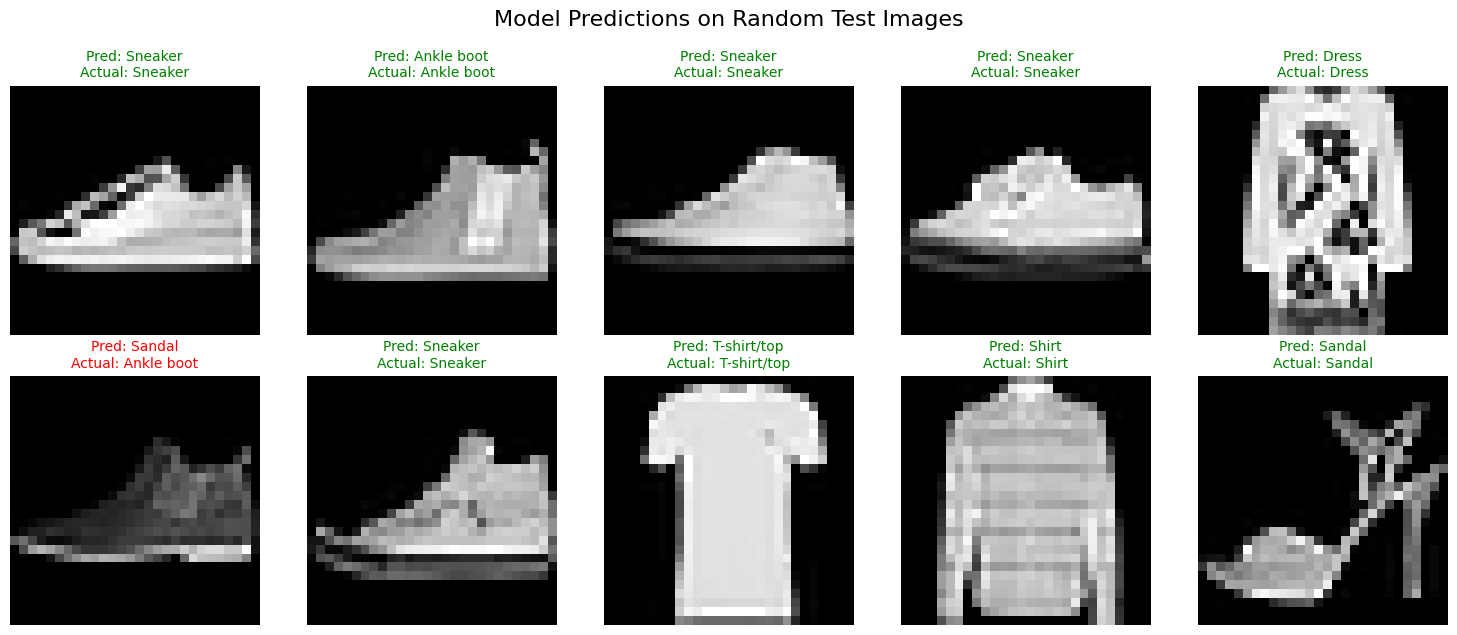

In [57]:
# define labels
clothing_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 10 random images from the test set
random_indices = np.random.choice(len(X_test), 10, replace=False)
# original images
sample_images = X_test[random_indices]
# PCA data for the model
sample_pca = pcaX_test[random_indices]
actual_labels = Y_test[random_indices]

# make predictions
predictions = final_model.predict(sample_pca)

# plot the results
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)

    # Reshape to 28x28 grid to see the picture
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')

    # green: correct - red: wrong
    color = 'green' if predictions[i] == actual_labels[i] else 'red'

    plt.title(f"Pred: {clothing_labels[predictions[i]]}\nActual: {clothing_labels[actual_labels[i]]}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Model Predictions on Random Test Images", fontsize=16, y=1.05)
plt.show()

As shown in the above plot, the model demonstrates a high degree of visual understanding, correctly identifying complex clothing items.

The correct classifications are highlighted in green, while any errors are marked in red.

### 8.4 Confusion Matrix

After getting our final accuracy score, we use a **Confusion Matrix** to look deeper into the results. While accuracy tells us how many images we got right, the matrix shows us exactly which items the model is confusing.
We do this to:

- Identify the 'weakest' clothing categories.
- Check if the model's mistakes make sense (e.g., confusing a Shirt with a Coat).
- See if the model is biased toward specific items

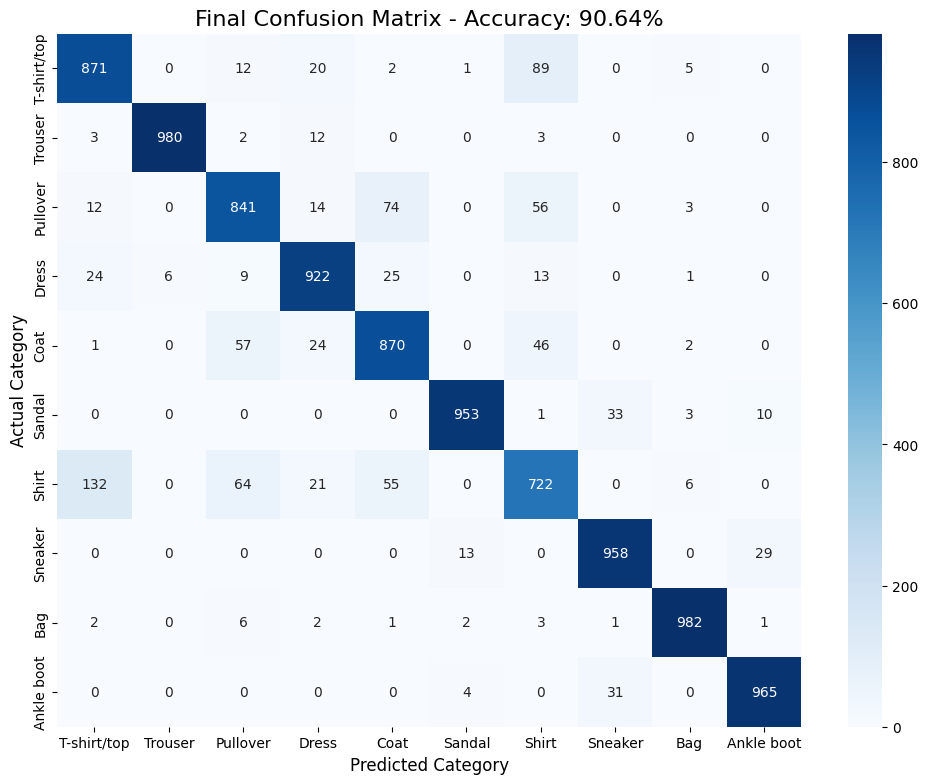

In [58]:
#create the comfusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# create the heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clothing_labels, yticklabels=clothing_labels)

plt.title(f'Final Confusion Matrix - Accuracy: {0.9064:.2%}', fontsize=16)
plt.ylabel('Actual Category', fontsize=12)
plt.xlabel('Predicted Category', fontsize=12)
plt.show()

Based on our final accuracy of 90.64% and the heatmap we generated, we can mention the following:

- The model is a 'master' at identifying Trousers and Bags. Their unique shapes make them very easy for the SVM to find.
- The most errors happen between Shirts, T-shirts, and Coats. This is logical because these items are very similar.
- Success of Tuning: The high score proves that using PCA (to shrink the data) and Random Search (to find the best C value) worked perfectly together.

To analyze the Confusion Matrix, we use four specific terms that describe the model's decisions. Let's use the 'Shirt' category as an example:

- True Positive (TP): The model correctly identified a Shirt. (The 'Correct' diagonal).
- True Negative (TN): The model correctly identified that an image was not a Shirt.
- False Positive (FP): The 'False Alarm.' The model thought an image was a Shirt, but it was actually something else (like a Coat).
- False Negative (FN): The 'Miss.' The model failed to recognize an actual Shirt and labeled it as something else.

### 8.5 Classification Report  - Metrics

In this section, we need to look deeper into how the model handles each specific clothing category (labels) while overall accuracy gives us a single number for success.

The Classification Report provides three key measurements—Precision, Recall, and F1-score—to give us a complete picture of the model's strengths and weaknesses for every clothing category.

In [59]:
#classification Report (Precision, Recall, F1)
print("Classification Report\n")
print(classification_report(Y_test, Y_pred, target_names=clothing_labels))

Classification Report

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.87      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.85      0.84      0.84      1000
       Dress       0.91      0.92      0.92      1000
        Coat       0.85      0.87      0.86      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.77      0.72      0.75      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



After the results and looking at the above numbers, we can see that our 90.64% accuracy is very consistent.

- The clothing categories like Trousers and Bags have F1-scores near 0.98, meaning the model almost never misses them.
- We can say that the shirts have the lowest score (around 0.78). This confirms our theory that the model sometimes confuses shirts with similar items like T-shirts or Coats.

Overall: The 'Macro Average' is very high, which proves that the model is performing well across the entire dataset, not just on one or two easy items.

##### 8.5.1 Performance Metrics Visualization

To make the Classification Report easier to understand, we created a bar chart of the F1-Scores. While the table gives us raw numbers, this chart helps us visually compare which clothing items the model identifies best. We focus on the F1-Score because it is the most balanced 'grade' for each category.

- Precision: "When the model says 'this is a Shirt,' how often is it actually a shirt?"
- Recall: "Out of all the real Shirts in the test set, how many did the model find?"
- F1-Score: "A single score that balances both Precision and Recall to give a final grade.


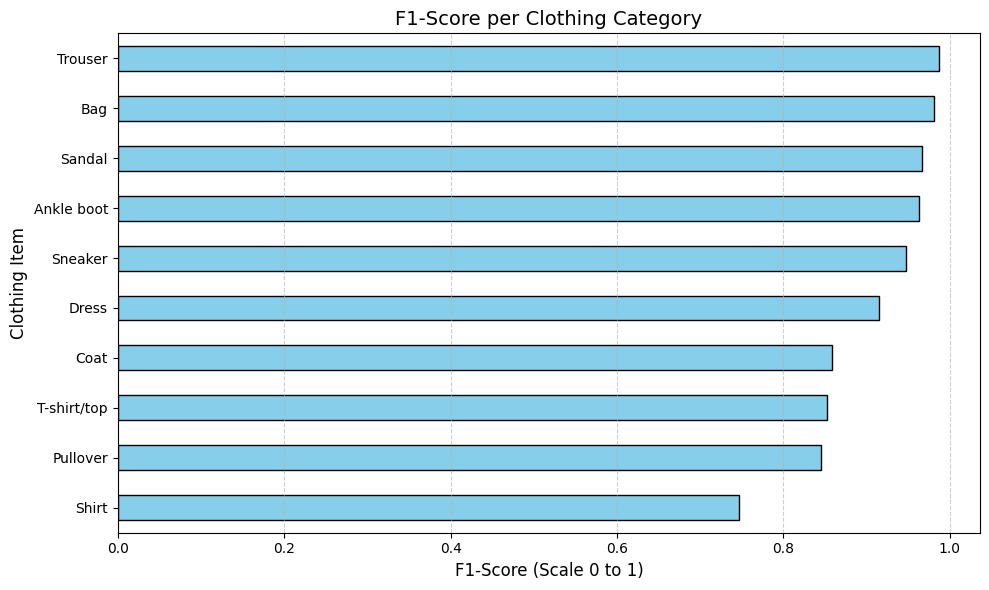

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# report data as dictionary
report_dict = classification_report(Y_test, Y_pred, target_names=clothing_labels, output_dict=True)

# convert to a DataFrame and pick only the 10 clothing categories
report_df = pd.DataFrame(report_dict).transpose()
f1_data = report_df.iloc[:10]['f1-score']

# bar plot
plt.figure(figsize=(10, 6))
f1_data.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('F1-Score per Clothing Category', fontsize=14)
plt.xlabel('F1-Score (Scale 0 to 1)', fontsize=12)
plt.ylabel('Clothing Item', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

After the result of F1-Score, we can mention the following:

- Clothing categories like Trousers, Bags, and Sandals have near-perfect scores (0.97–0.99). Their unique shapes make them very easy for the SVM to distinguish from other categories.

- The lower scores for Shirts (0.75), Pullovers (0.84), and T-shirts (0.85) show that the model occasionally struggles with items that share similar grayscale outlines.

- Robustness: Even our "weakest" category (Shirt) has a score of 0.75, which is considered a strong result for this dataset.

Last but not least, with other words, we can say that the bar chart represents the 'Final Grade' for each clothing category. While our overall accuracy is 90.64%, this view shows that our model is almost perfect at identifying distinct shapes like Trousers and Bags. The lower bar for Shirts confirms our error analysis: the model sometimes confuses similar upper-body garments, but it maintains a high standard across the entire dataset.

### 8.6 Error Analysis

The 90.64% accuracy is excellent, but we looked at the mistakes to understand the model better.

- We found that the model makes 'logical' mistakes. For example, it often confuses Shirts with Coats or T-shirts.

This happens because, in a small grayscale image, these items have the same basic shape. The model has learned the general shape of clothes perfectly, but it sometimes misses some details that were lost during the data reduction (PCA).


### 8.7 Limitations

After all, we can say that there are two main limits to this study:

- Information Loss: By using PCA to keep 95% of the data, we intentionally threw away 5%. Those small details might have helped tell the difference between some clothing categories.

- Simple Learning: The SVM algorithm is very fast, but it looks at pixels as a list - it doesn't 'see' shapes.

### 8.8 Future Work

Finally, we can get better results in the future:
- Data Augmentation: Create 'new' training images by slightly rotating or flipping the originals to help the model learn better.
- Ensembles: Combine the SVM with other models to let them 'vote' on the final answer.
- Deep Learning use

## Chapter 9: Discussion & Conclusions

The final chapter summarizes the results of our machine learning pipeline and evaluates the effectiveness of our methodology. After all these steps and techniques - starting from baseline testing to hyperparameter optimization, we have achieved a robust model for the Fashion-MNIST dataset. This section provides a final discussion on the model’s performance, technical documentation for reproducibility, and suggestions for future research.

##### 9.1 Performance Summary

It is important to say that our study concludes that a SVM with an RBF kernel, optimized via Randomized Search, in highly effective for image classification.

The project successfully built a model that can identify clothing items with 90.64% accuracy. We started with a simple baseline and improved it by over 5% through two main steps:

- PCA: We shrank the data from 784 features to 188. This made the model much faster to train.
- Random Search (optimizer): We found the perfect 'C' value (3.2204) for our SVM.

The final model is very efficient—it takes less than 3 minutes to train on 60,000 images. This proves that you don't always need super-powerful computers to get high-quality results. By using smart data cleaning and choosing the right settings, we created a robust system that correctly identifies nearly all fashion items.

##### 9.2 Data dictionary

The following table serves as a reference for the most important variables used in this notebook.

| Variable Name | Description |
| :--- | :--- |
| `df_train` | training (60k) dataframe |
| `df_test` | testing (10k) dataframe|
| `rescaledX` | training features after applying Min-Max scaling.|
| `rescaledX_test` | test features after applying Min-Max scaling (using the training scaler) |
| `standardizedX` | training features transformed to have a mean of 0 and variance of 1.|
| `normalizedX` | training features scaled so that each row has a length of 1 (Unit Norm). |
| `binarizedX` | training features after thresholding (Experimental). |
| `n_comp` | number of components (188) required to preserve 95% of the variance. |
| `pca` | PCA object used for initial dimensionality analysis. |
| `pca_final` | optimized PCA object configured with n_components=188 |
| `pca_X` | final reduced training set used for SVM modeling.|
| `pcaX_test` | final reduced test set used for model evaluation. |
| `cm` | confusion matrix |
| `X_sample` | testing (10k) dataframe |
| `X_train_pca` | training features reduced to 188 components. |
| `X_test_pca` | test features reduced to 188 components. |
| `Y_pred` | final predicted labels from the optimized model. |
| `best_svm` | final SVC object with C=3.2204. |
| `report_dict` | report data dictionary (from classification report() |
| `final_model` | Support Vector Machine (SVM) model for PCA-reduced dataset|

#References

<a name="ref1"></a> [1] A. Nentidis, "Machine Learning Lecture Slides," Harokopio University of Athens, eClass, 2026. [Online]. Available: https://eclass.hua.gr/modules/document/index.php?course=DIT293

<a name="ref3"></a> [2] Scikit-learn Developers, "RBF Kernel Documentation: sklearn.gaussian_process.kernels.RBF," Scikit-learn v1.3.2, 2023. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.RBF.html

<a name="ref3"></a> [3] Zalando Research, "Fashion-MNIST Dataset," Kaggle, 2017. [Online]. Available: https://www.kaggle.com/datasets/zalando-research/fashionmnist


